# Education Spending Broad Benchmark

## Notes 

Focus of this notebook is to compare expenditures by function to a reference group.

Key measures are nominal vs. inflation-adjusted spending, and spending growth.

See SES at 
https://ctdatahaven.org/data-dashboard/connecticut-town-data-viewer/


## Filter to "Peer Group"
Dropping Southington - it is just too large!

In [1]:
# peer selection
PEERVAL = 'DRG B'
PEERVAR = "finprojB"
peer_condition = f"{PEERVAR} > 0"

SocioEconomic Data from National Center for Education Statistics https://nces.ed.gov/programs/edge/Home

In [2]:
import os
from os import path, mkdir
import glob
import re
import warnings
from datetime import datetime
import numpy as np
from scipy import stats
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [3]:
#make directory if needed
try:
    mkdir(f"./charts/peer_districts/{PEERVAR}")
except FileExistsError:
    pass

In [4]:
def split_function(x):
    return x.replace(" - ", ":\n").title()

In [5]:
# Define a custom formatter function

def dollar_i(x, pos):
    return f"${x:,.0f}"
    
def dollar_k(x, pos):
    return f"${int(x/1000):,}K"
    
def dollar_k1(x, pos):
    return f"${int(x/1000):,.1f}K"

# for when data is "in thousands"
def dollar_mm(x, pos):
    return f"${int(x/1000):,}MM"

# for when data is "in thousands"
def dollar_bb(x, pos):
    return f"${(x/1000000):,.1f}B"

# for when data is "in ones" - actual million
def dollar_realmm(x, pos):
    return f"${(x/1000000):,.1f}MM"
    
# for when data is "in ones" - actual billion
def dollar_realbb(x, pos):
    return f"${(x/1000000000):,.1f}B"
    
def comma(x, pos):
    return f"{int(x):,}"

def qty_k(x, pos):
    return f"{(x/1000):,.1f}K"

def percfmt(x, pos):
    return f"{x:.1%}"

def perc2fmt(x, pos):
    return f"{x:.2%}"
    
def percifmt(x, pos):
    return f"{x:.0%}"
    
# Apply the formatter to the y-axis
dollari_formatter = ticker.FuncFormatter(dollar_i)
dollar_k_formatter = ticker.FuncFormatter(dollar_k)
dollar_k1_formatter = ticker.FuncFormatter(dollar_k1)
dollar_bb_formatter = ticker.FuncFormatter(dollar_bb)
dollar_realbb_formatter = ticker.FuncFormatter(dollar_realbb)
dollar_mm_formatter = ticker.FuncFormatter(dollar_mm)
dollar_realmm_formatter = ticker.FuncFormatter(dollar_realmm)
perc_formatter = ticker.FuncFormatter(percfmt)
perc2_formatter = ticker.FuncFormatter(perc2fmt)
perci_formatter = ticker.FuncFormatter(percifmt)

k_formatter = ticker.FuncFormatter(qty_k)
comma_formatter = ticker.FuncFormatter(comma)

In [6]:
# for plotting
rundate = datetime.now().strftime('%a %d %b %Y %H:%M:%S EDT')
software = f"Seaborn={sns.__version__}"

png_metadata = {
'Title': "Social Security Income",
'Author': 'Joel Danke',
'Description': "Based on OASDI data https://www.ssa.gov/policy/docs/statcomps/oasdi_zip/2022/index.html",
'Creation Time': rundate,
'Software': software}

## Read data

In [7]:
# all have the "grouping" vars JSG, % w/Bachelors, etc.
totalstaff = pd.read_parquet('/Users/joel/Desktop/Granby Benchmarking/education/dataframes/totalstaff.parquet')
function_exp = pd.read_parquet('/Users/joel/Desktop/Granby Benchmarking/education/dataframes/expenditures.parquet')
accountability = pd.read_parquet('/Users/joel/Desktop/Granby Benchmarking/education/dataframes/accountability.parquet')

# just district & year, also Category is used to split
school_accountability = pd.read_parquet('/Users/joel/Desktop/Granby Benchmarking/education/dataframes/accountability_schools.parquet')

In [8]:
# income data
income_vars =  ['District', 'Fiscal Year End', 'Size of adjusted gross income', 'Income Per Taxpayer', 'Equalized Net Grand List Per Taxpayer',
                'Real Income Per Taxpayer', 'Real Disposable Income Per Taxpayer', 'Real Equalized Net Grand List Per Taxpayer',
                'Debt Service Share Of Budget', 'Education Share Of Budget', 'Education Share Of Eq Grand List', 'Education Share Of Income', 'Taxpayers']

district_total_income = pd.read_parquet('/Users/joel/Desktop/Granby Benchmarking/education/dataframes/district_incomes.parquet')[income_vars]
district_total_income = district_total_income[district_total_income['Size of adjusted gross income'] == 'Total'].copy()

# re-use 2022 as 2023
district_total_2023 = district_total_income[district_total_income['Fiscal Year End'] == 2023].copy()
district_total_2023['Fiscal Year End'] = district_total_2023['Fiscal Year End'] + 1
district_total_income = pd.concat([district_total_income, district_total_2023], ignore_index=True)

# make school year as the one that starts the next fiscal year
district_total_income['School Year'] = (district_total_income['Fiscal Year End'] + 1).astype('str')

In [9]:
# population (has extra year from municipal grand list
popdf_districts = pd.read_parquet('/Users/joel/Desktop/Granby Benchmarking/education/dataframes/population_district.parquet')
# as string to join
popdf_districts['School Year'] = popdf_districts['Year'].astype('str')
popdf_districts.drop(columns=['Year'], inplace=True)

### Expenditures

#### Object Expenditures
Used as an estimate of overhead costs. Salaries are not subdivided by instructional, admin, custodial.

**Purchased Services** – Services rendered by organizations or
personnel not on the payroll of the school district. Although
a product may or may not result from the transaction, the
primary reason for the purchase is the service provided.  
**Supplies** – Items that are consumed, are worn out, or have
deteriorated through use or items that lose their identity
through fabrication or incorporation into different or more
complex units or substances. Includes, for example, 
instructional supplies such as textbooks, office supplies,
electricity, and fuel.  
**Property** – Purchases of equipment, furniture, equipment,
and for minor school construction projects such as for roof
replacement, energy conservation, or updates to comply
with building codes.  
**Other** – Expenditures not included in the other objects.  
**Tuition** – Line shown if greater than 5 applicable pupils.
Reimbursements to other educational entities for
instructional services to students residing within the legal
boundaries of the paying school district.


**Budget Book**  
**Largest Benefit Increase + \$346K**: Board's contribution to the Granby Health Benefit Fund for employee medical/dental insurance. The budget includes a slight premium increase, as well as census changes. Additionally, **commencing in FY27,** additional OPEB contributions are being paid by the Board of Education to meet the Actuarily Determined Contribution (ADC).  

**Purchased Services**:  
**Educational Services \$595K**: Includes funds for services including copiers, substitutes, curriculum development activities, **school resource officer benefits**, purchased instructional services for virtual classes, etc.   
**Support Services \$540K**: Includes funds for health service and physician fee contracted services. Contracted nursing services will increase 5% in FY27.  
**Support Services \$262K**: Includes funds for special education support services for evaluation services required by law. This budget also supports the Alternative Learning Center at the middle school/high school and training for teachers to deliver specialized reading instruction. The increase reflects **higher School Resource Officer benefits**, increased subsitute service rates, and hazardous waste disposal costs for science laboratories.  
**P/L Insurance \$120K**: Includes funds for property, auto, legal liability and cyber insurance.  
**Legal Fees \$69K**: Includes funds for legal fees associated with legal compliance, employee relations and grievances, internal investigations, risk management and defense, complex matters surrounding education, as well as collective bargaining, complex special education matters and due process hearings.

#### Functional Expenditures

**Instruction**  
Activities dealing directly with the interaction between teachers and students. Teaching may be provided for students in a school classroom or in another location.  

**Support services – students**  
Activities providing student support services designed to assess and improve the well-being of students and to supplement the teaching process. This includes guidance, social, and health services.  

**Support Services – instruction**  
Activities assisting the instructional staff with the content and process of providing learning experiences for students not reported as Improving Instruction or Library and media service.  

**Support Services – general administration**  
Activities of the board of education and the superintendent's office.  

**Support Services – school-based administration**  
Activities concerned with the administrative responsibility of directing and managing the operation of a school, such as the principal's office.  

**Central and other support services**  
Activities that support other administrative and instructional functions, including fiscal services, human resources, planning, and administrative information technology, and other support services not included elsewhere.  

**Operation and maintenance of plant**  
Activities concerned with keeping the physical plant open, comfortable and safe for use and with keeping the grounds, buildings, and equipment in effective working condition and state of repair.  

**Student transportation services**
Activities providing transportation to and from home, for field trips, and for athletic activities.  

**Food services**  
Activities concerned with providing food to students and staff in a school or school district. This report includes only expenditures from local funds used to cover an operating deficit in the food service program, where revenue from child nutrition grants, fees, and other sources is insufficient to cover all expenses.

**Enterprise operations**  
Activities for enterprise operations, i.e. activities that are financed and operated in a manner similar to private business enterprises, for example a school bookstore. Also includes athletics, bands, dramatics, and any school activity paid by local appropriations. Does not include any student activity funds.

**Minor school construction**  
Activities concerned with minor school construction projects, such as for roof replacement, energy conservation, or updates to comply with building codes. (Applies to years earlier than 2019-20 only.)  

In [10]:
# filter to remove non-essential schools, functions
peer_expenditures = function_exp[(function_exp['Organization Type'].isin(['Public School Districts', 'Regional School Districts'])) &
                                (~function_exp['Function'].isin(['Minor school construction', 'Enterprise operations', 'Food services'])) &
                                (function_exp['High Grade'] == 12)]\
                    .query(peer_condition).copy()

# not sure this is used
peer_ave = peer_expenditures.groupby(['Function', 'Year'])['PPE Growth'].median().reset_index().rename(columns={'PPE Growth': 'Median PPE Growth'})
peer_expenditures = peer_expenditures.merge(peer_ave, how='left', on=['Function', 'Year'])

peer_expenditures = peer_expenditures[~peer_expenditures['District'].str.startswith('Southington')]
peer_expenditures['School Year'] = peer_expenditures['Year'].str.slice(0,4)
peer_expenditures.sort_values(by=['School Year', 'Function', 'District'], inplace=True)

In [11]:
peer_expenditures.groupby('Function').agg({'District': 'nunique', 'Year': 'nunique'})

,District,Year
Function,,
Administration and Support Services,18,5
Central and other support services,18,8
Employee Benefits,18,8
Instruction,18,13
Operation and maintenance of plant,18,13
Salaries,18,8
Services And Supplies,18,8
Student transportation services,18,13
Support services - general administration,18,13


In [12]:
peer_expenditures.groupby('Function').agg({'Year': 'max'})

,Year
Function,
Administration and Support Services,2016-17
Central and other support services,2024-25
Employee Benefits,2024-25
Instruction,2024-25
Operation and maintenance of plant,2024-25
Salaries,2024-25
Services And Supplies,2024-25
Student transportation services,2024-25
Support services - general administration,2024-25


### Staffing
This includes regional schools that are 7-12 or 9-12 only. It might be "more fair" to include only K-12 institutions.

In [13]:
# ignore elementary districts
totalstaff['SpecialEd Share Of Ed'] = (totalstaff['SpecialEd'] / (totalstaff['Educational'] + totalstaff['SpecialEd']))
peerstaff = totalstaff[(totalstaff['Organization Type'].isin(['Public School Districts', 'Regional School Districts'])) &
                       (totalstaff['High Grade'] == 12) & (totalstaff['Year'] > '2009')]\
            .query(peer_condition).copy()

peerstaff = peerstaff[~peerstaff['District'].str.startswith('Southington')]
peerstaff.sort_values(by=['Granby', 'Year'], ascending=[False, True], inplace=True)

### Accountability

**NO Southington**  
**No Covid Years**  

Connecticut's Next Generation Accountability reports for 2017-18 didn't show science scores because the state administered a field test (Smarter Science Field Test) instead of the regular CMT/CAPT science tests. 

In 2017-18, Connecticut's Next Generation Accountability system integrated Smarter Balanced tests (ELA/Math) with the new Next Generation Science Standards (NGSS) assessment, a field test/pilot for Grades 5, 8, and 11, aligning science with modern standards and transitioning from older science measures to a more comprehensive, standards-based approach for college/career readiness. Schools used multiple indicators, including these assessments, to show progress. 

In [14]:
# remove nonessential schools
peer_accountability = accountability[(accountability['Organization Type'].isin(['Public School Districts', 'Regional School Districts'])) &
                                     (accountability['High Grade'] == 12)]\
                     .query(peer_condition).copy()

peer_accountability = peer_accountability[~peer_accountability['District'].str.startswith('Southington')]

peer_accountability.sort_values(by=['Granby', 'Year'], ascending=[False, True], inplace=True)
peer_accountability['School Year'] = peer_accountability['Year'].str.slice(0,4).astype('int')

## Combine accountability, expenditures, staffing

Select columns to avoid duplicates.

In [15]:
# Avoid duplicating clustering variables when getting staff data
peerdrop = [x for x in peerstaff.columns if ((x in peer_expenditures.columns) & (x not in ['Year', 'District']))]

# For accountability index select only necessary variables
values = ['Math PI', 'Math Growth', 'ELA PI', 'ELA Growth', 'Science PI',
          'CCR - Taking Courses', 'CCR - Passing Exams', 'Postsecondary Entrance', 
          'On-track to HS Graduation', '4-yr Graduation', 'Chronic Absenteeism',
          'Physical Fitness', 'Arts Access', 'Accountability Index']

high_need = ['ELA PI - High Needs',  'ELA Growth - High Needs', 
             'Math PI - High Needs', 'Math Growth - High Needs',
             'Science PI - High Needs', 'Chronic Absenteeism - High Needs', '6-yr Graduation - High Needs']

### Total Expenditures

In [16]:
# filter to only one Function per district per year
# get other type of expenditures for reporting only

_benefits = peer_expenditures[peer_expenditures['Function'] == 'Employee Benefits'][['Year', 'District', 'PPE', 'Expenditures', 'Real Expenditures']]\
                             .rename(columns={'PPE': 'Benefits Per Student', 'Expenditures': 'Benefits', 'Real Expenditures': 'Real Benefits'}).copy()

_salaries = peer_expenditures[peer_expenditures['Function'] == 'Salaries'][['Year', 'District', 'PPE', 'Expenditures', 'Real Expenditures']]\
                             .rename(columns={'PPE': 'Salaries Per Student', 'Expenditures': 'Salaries', 'Real Expenditures': 'Real Salaries'}).copy()

_services = peer_expenditures[peer_expenditures['Function'] == 'Services And Supplies'][['Year', 'District', 'PPE', 'Real PPE']]\
                             .rename(columns={'PPE': 'Purchased Services Per Student', 'Real PPE': 'Real Purchased Services Per Student'}).copy()

In [17]:
_salaries[_salaries['District'].str.startswith('Granby')]

,Year,District,Salaries Per Student,Salaries,Real Salaries
1055,2017-18,Granby School District,10213.0,19047739.0,18892630.50
1056,2018-19,Granby School District,10513.0,19659130.0,19142101.83
1057,2019-20,Granby School District,11101.0,19859466.0,19039437.43
1058,2020-21,Granby School District,11937.0,20507589.0,19401876.08
1059,2021-22,Granby School District,11982.0,21005135.0,18722656.01
1060,2022-23,Granby School District,12405.0,21398947.0,18075877.65
1061,2023-24,Granby School District,12835.0,22191381.0,18240490.71
1062,2024-25,Granby School District,13358.0,22615110.0,18095127.98


In [18]:
_benefits[_benefits['District'].str.startswith('Granby')]

,Year,District,Benefits Per Student,Benefits,Real Benefits
1021,2017-18,Granby School District,2262.0,4218366.0,4184015.23
1022,2018-19,Granby School District,2445.0,4571701.0,4451466.88
1023,2019-20,Granby School District,2729.0,4881704.0,4680130.77
1024,2020-21,Granby School District,3099.0,5324880.0,5037777.08
1025,2021-22,Granby School District,3236.0,5671937.0,5055607.85
1026,2022-23,Granby School District,3292.0,5678845.0,4796970.03
1027,2023-24,Granby School District,3336.0,5767286.0,4740494.82
1028,2024-25,Granby School District,3727.0,6309932.0,5048793.80


In [19]:
# ONLY "total" expenditures, accountability index
peer_combined = peer_expenditures[peer_expenditures['Function'] == 'Total']\
                .merge(_benefits,  how='left', on=['Year', 'District'])\
                .merge(_salaries,  how='left', on=['Year', 'District'])\
                .merge(_services,  how='left', on=['Year', 'District'])\
                .merge(peer_accountability[['Year', 'District'] + values], how='left', on=['Year', 'District'])\
                .merge(peerstaff.drop(columns=['Town', 'Low Grade', 'High Grade','Organization Type', 'Type', 'Granby', 'Pupils', 'Size'] + peerdrop),
                                            how='left', on=['Year', 'District'])\
                .merge(popdf_districts, how='left', on=['School Year', 'District'])\
                .merge(district_total_income, how='left', on=['School Year', 'District'])

peer_combined['% Student'] = peer_combined['Enrollment'] / peer_combined['Population']
peer_combined['Expenditures Per Student'] = peer_combined['Expenditures'] / peer_combined['Enrollment']
peer_combined['Real Expenditures Per Student'] = peer_combined['Real Expenditures'] / peer_combined['Enrollment']

peer_combined['Benefits Per FTE'] = peer_combined['Benefits'] / peer_combined['FTE Count']
peer_combined['Real Benefits Per FTE'] = peer_combined['Real Benefits'] / peer_combined['FTE Count']

peer_combined['Salaries Per FTE'] = peer_combined['Salaries'] / peer_combined['FTE Count']
peer_combined['Real Salaries Per FTE'] = peer_combined['Real Salaries'] / peer_combined['FTE Count']

peer_combined['Non-Instruction $ Per Student'] = peer_combined['Expenditures Per Student'] - peer_combined['Instruction $ Per Student']
peer_combined['Real Non-Instruction $ Per Student'] = peer_combined['Real Expenditures Per Student'] - peer_combined['Real Instruction $ Per Student']

peer_combined['Payroll Less Instruction Per Student'] = peer_combined['Payroll Per Student'] - peer_combined['Instruction $ Per Student']
peer_combined['Real Payroll Less Instruction Per Student'] = peer_combined['Real Payroll Per Student'] - peer_combined['Real Instruction $ Per Student']

### Instructional Expenditures

In [20]:
# ONLY "instructional" expenditures only
peer_instruction = peer_expenditures[peer_expenditures['Function'] == 'Instruction']\
                   .merge(peer_accountability[['Year', 'District'] + values], how='left', on=['Year', 'District'])\
                   .merge(peerstaff.drop(columns=['Town', 'Low Grade', 'High Grade','Organization Type', 'Type', 'Granby', 'Pupils', 'Size'] + peerdrop),
                                            how='left', on=['Year', 'District'])

peer_instruction.sort_values(by=['District', 'Year'], inplace=True)
peer_instruction.reset_index(inplace=True, drop=True)

### Peer Overview

In [21]:
idx = pd.IndexSlice
slice_ = idx[idx["Granby School District"], idx[:]]

_d = peer_combined.query('Year == "2024-25"')[['District', 'Equalized Net Grand List Per Taxpayer', 'Income Per Taxpayer',
                                               'Education Share Of Income', 'Expenditures', 'Enrollment', 'FTE Count', 'Instructional Share Of FTE',
                                               'Accountability Index',
                                              'High Needs Students Share of Enrollment', 'Students w/ Disabilities Share of Enrollment',
                                               'Expenditures Per Student', 'Instruction $ Per Student', 'Non-Instruction $ Per Student',
                                               'Payroll Less Instruction Per Student', 'Purchased Services Per Student']]\
        .rename(columns = {'High Needs Students Share of Enrollment': 'High Needs %',
                          'Students w/ Disabilities Share of Enrollment': 'w/Disability %',
                          'Instructional Share Of FTE': 'Instructor %'})\
    .sort_values('Instruction $ Per Student').copy()


_d.drop(columns=['Expenditures Per Student'], inplace=True)

_d.set_index('District', inplace=True)
_d.style.format({"Accountability Index": "{:,.1f}"} | { "Expenditures": lambda x: f"${(x/1000000):,.1f}MM"} |
                  { x: "${:,.0f}" for x in ["'Payroll Less Instruction Per Student'", 'Instruction $ Per Student', 'Non-Instruction $ Per Student', 'Payroll Less Instruction Per Student',
                                            'Non-Instruction $ Per Student', 'Purchased Services Per Student', 'Equalized Net Grand List Per Taxpayer', 'Income Per Taxpayer']} |
                  { x: "{:,.1%}" for x in ['Education Share Of Income', 'w/Disability %', 'High Needs %', 'Instructor %']} |
                  { x: "{:,.0f}" for x in ['Enrollment', 'FTE Count']} )\
    .set_properties(**{"background-color": "#ffffb3", 'font-weight' : 'bold'}, subset=slice_)\
    .set_caption(f"2024-2025 School Year Key Stats: {PEERVAL}")\
    .set_table_styles([{'selector': 'caption', 'props': [('font-weight', 'bold'), ('font-size', '14px')]}])


,Equalized Net Grand List Per Taxpayer,Income Per Taxpayer,Education Share Of Income,Expenditures,Enrollment,FTE Count,Instructor %,Accountability Index,High Needs %,w/Disability %,Instruction $ Per Student,Non-Instruction $ Per Student,Payroll Less Instruction Per Student,Purchased Services Per Student
District,,,,,,,,,,,,,,
Trumbull School District,"$279,447","$93,695",5.7%,$141.0MM,"6,943","1,171",63.4%,84.7,33.4%,15.2%,"$10,881","$9,420","$4,898","$3,634"
South Windsor School District,"$281,334","$82,630",5.9%,$99.4MM,"5,125",882,65.8%,82.3,33.6%,12.9%,"$11,721","$7,678","$3,984","$3,099"
Farmington School District,"$358,675","$113,281",4.0%,$90.1MM,"4,195",797,62.9%,85.3,31.6%,13.4%,"$12,922","$8,556","$3,532","$3,740"
Rocky Hill School District,"$288,771","$74,345",5.3%,$57.2MM,"2,539",519,62.3%,82.8,39.3%,15.4%,"$12,928","$9,614","$5,178","$3,867"
Cheshire School District,"$280,166","$102,813",4.4%,$91.8MM,"4,317",880,60.1%,85.4,29.8%,14.7%,"$13,277","$7,980","$3,832","$3,622"
Brookfield School District,"$305,868","$88,660",5.0%,$57.5MM,"2,542",470,60.6%,81.9,34.1%,14.2%,"$13,303","$9,313","$3,819","$4,096"
Granby School District,"$236,361","$91,622",5.1%,$39.0MM,"1,709",327,65.4%,82.8,30.7%,17.5%,"$13,396","$9,444","$3,689","$4,373"
Monroe School District,"$305,784","$87,743",6.0%,$74.0MM,"3,458",584,64.9%,79.6,28.1%,17.2%,"$13,456","$7,939","$3,540","$3,323"
Simsbury School District,"$271,677","$113,677",4.4%,$93.7MM,"4,127",738,64.3%,81.4,30.7%,17.8%,"$13,526","$9,180","$4,334","$3,732"


## Color Scheme

In [22]:
# color scheme
school_cols = {x:(0.69, 0.77, 0.87, .4) for x in peer_combined['District'].unique()}
school_cols = school_cols | {'Granby School District': 'black', 'Average': 'darkblue'}

peer_cols = {3: (0.19, 0.27, 0.57, .45),
             2: 'black',
             1: (0.529, 0.808, 0.922, .45)}

flag_cols = {0:(0.69, 0.77, 0.87, .4), 1:'black'}

## Inflation Adjusted Spending Growth
### Shrinking Enrollment Drives Costs

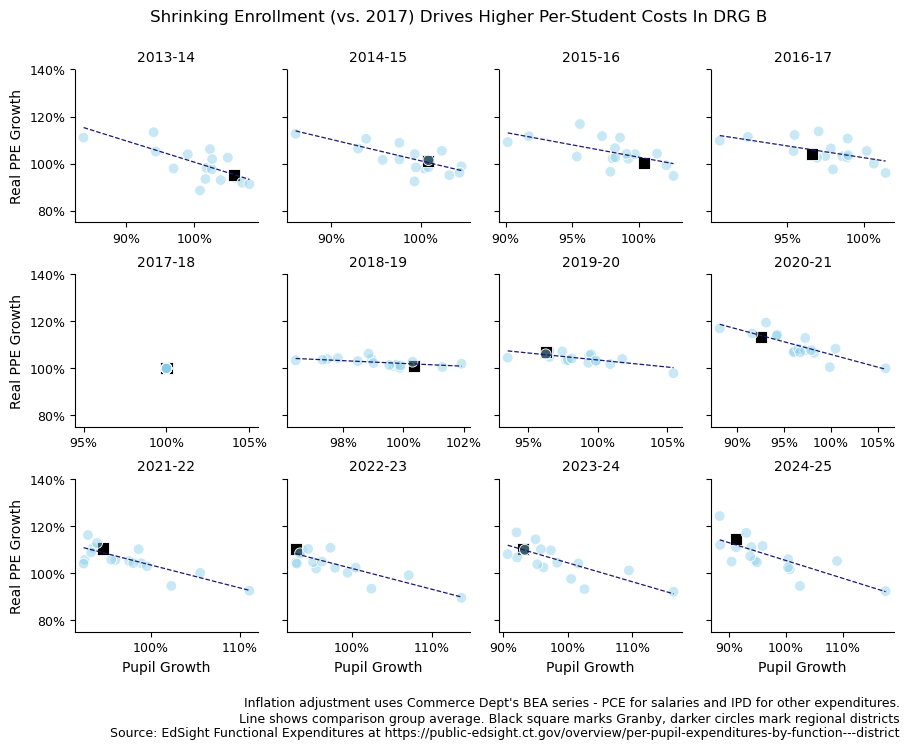

In [23]:
# limit to 12 years
g = sns.relplot(data=peer_expenditures[(peer_expenditures['Function'] == 'Instruction') &
                     (peer_expenditures['Year'] >= sorted(peer_expenditures['Year'].unique())[-12:][0])],
               x='Pupil Growth', y='Real PPE Growth', 
               col='Year', col_wrap=4, facet_kws={'sharex':False},
               height=2.5, aspect=.9, palette=peer_cols, legend=None,
               style='Granby', markers=['o','s'],
               size='Granby', sizes=[60, 76],
               hue = PEERVAR)

g.fig.suptitle(f"Shrinking Enrollment (vs. 2017) Drives Higher Per-Student Costs In {PEERVAL}")

g.set_titles(col_template="{col_name}")
g.map_dataframe(sns.regplot, x='Pupil Growth', y='Real PPE Growth',
                scatter=False, ci=None, robust=True,
                line_kws={'ls': '--', 'color': 'midnightblue', 'lw': .9})

g.set(ylim=(.75,1.4))

for ax in g.axes.flat:
    ax.tick_params(axis='both', labelsize=9)
    ax.yaxis.set_major_formatter(perci_formatter)
    ax.xaxis.set_major_formatter(perci_formatter)

plt.subplots_adjust(top=.9, bottom=0.15)
line2 = "Line shows comparison group average. Black square marks Granby, darker circles mark regional districts\n"
line1 = "Inflation adjustment uses Commerce Dept's BEA series - PCE for salaries and IPD for other expenditures.\n"
line3 = "Source: EdSight Functional Expenditures at https://public-edsight.ct.gov/overview/per-pupil-expenditures-by-function---district"
g.fig.text(.99, .01, line1 + line2 + line3, ha='right', fontsize=9)

plt.savefig(f"./charts/peer_districts/{PEERVAR}/spending_growth_v_student_growth.png", dpi=200, metadata=png_metadata)   
    
plt.show()

### By Functional Expenditure

In [24]:
peer_expenditures['Function'].value_counts()

Function
Instruction                                       234
Operation and maintenance of plant                234
Student transportation services                   234
Support services - general administration         234
Support services - instruction                    234
Support services - school based administration    234
Support services - students                       234
Central and other support services                144
Employee Benefits                                 144
Salaries                                          144
Services And Supplies                             144
Total                                             144
Tuitition                                         144
Administration and Support Services                90
Name: count, dtype: int64

### Basis for tuition is only outplaced

In [25]:
peer_expenditures.query('(Function.str.startswith("Tuiti")) & (Granby == "Granby")')\
                    [['Year', 'Pupils', 'PPE', 'Real PPE']].sort_values(by='Year')\
                 .style.format({"Pupils": "{:,.0f}"} |
                              { x: "${:,.0f}" for x in ["PPE", "Real PPE"]})\
                 .hide(axis="index")

Year,Pupils,PPE,Real PPE
2017-18,73,"$24,053","$23,857"
2018-19,75,"$27,111","$26,398"
2019-20,78,"$23,576","$22,603"
2020-21,76,"$24,878","$23,537"
2021-22,82,"$27,395","$24,418"
2022-23,76,"$33,135","$27,989"
2023-24,76,"$33,653","$27,662"
2024-25,76,"$35,573","$28,463"


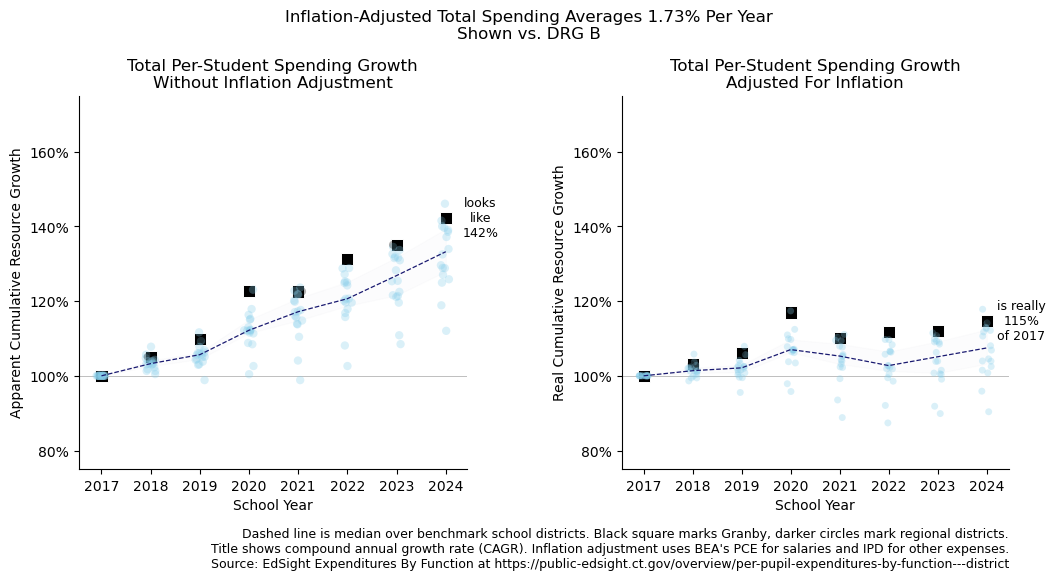

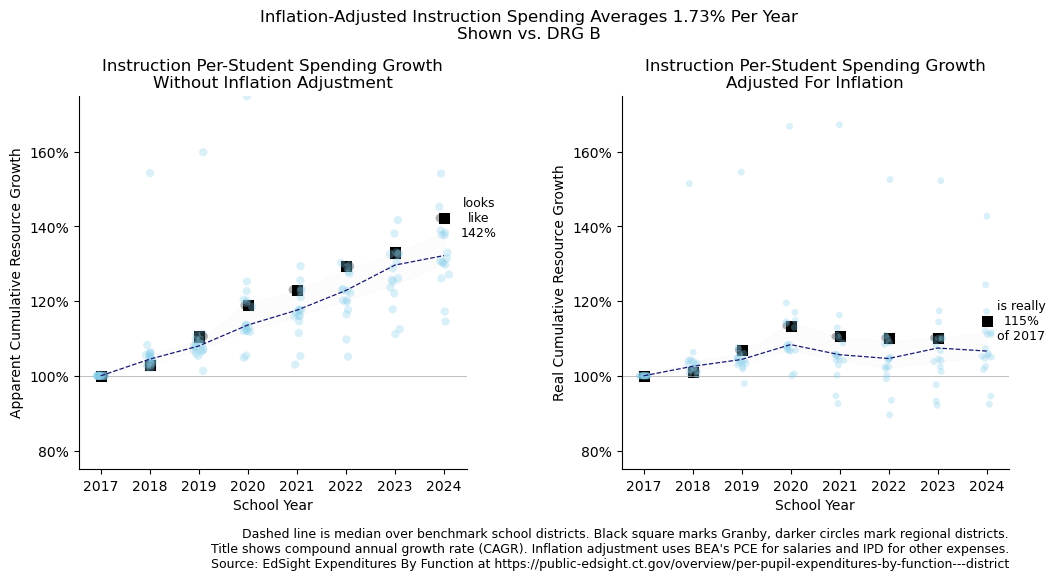

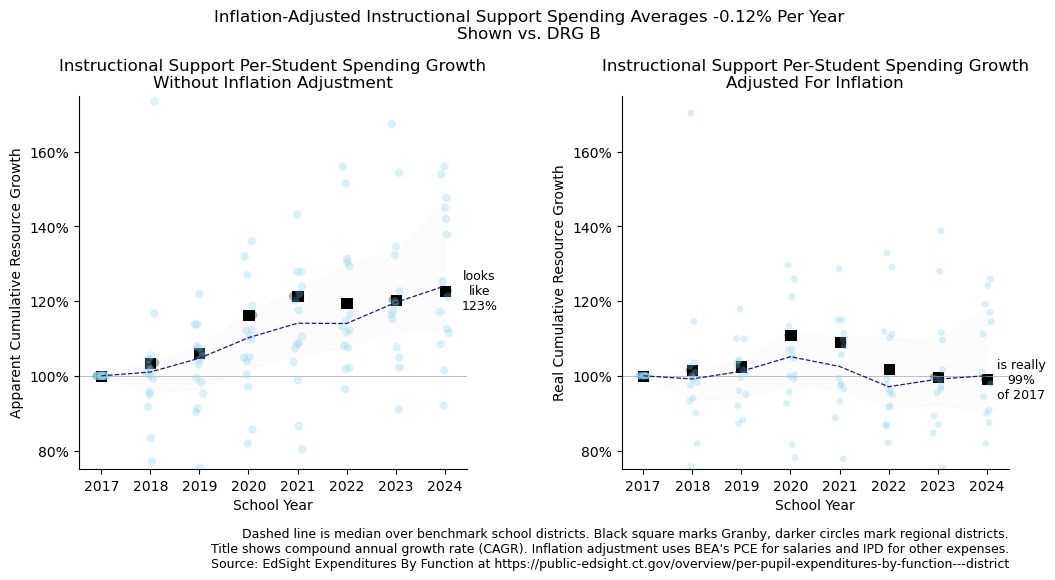

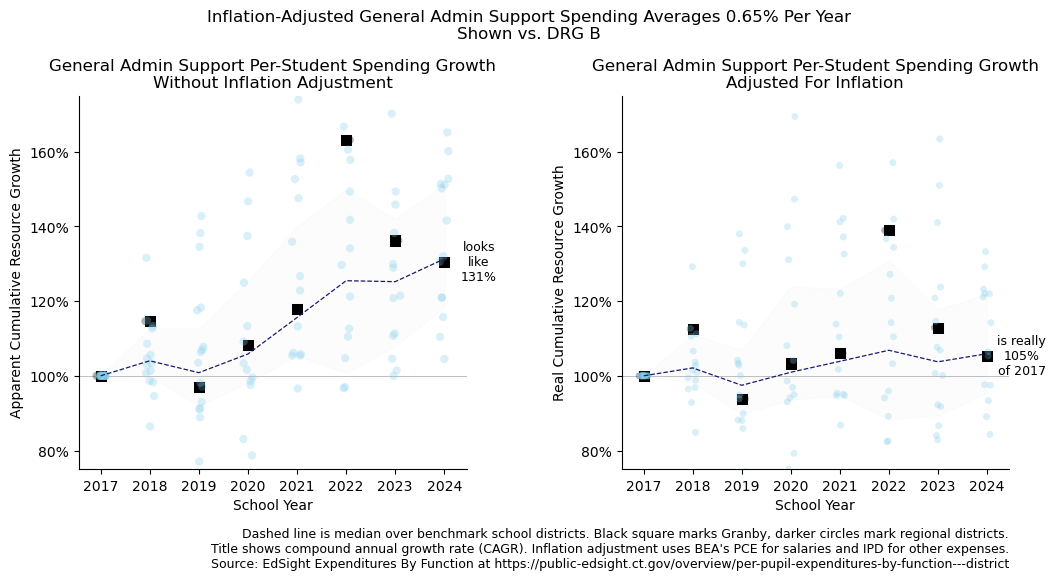

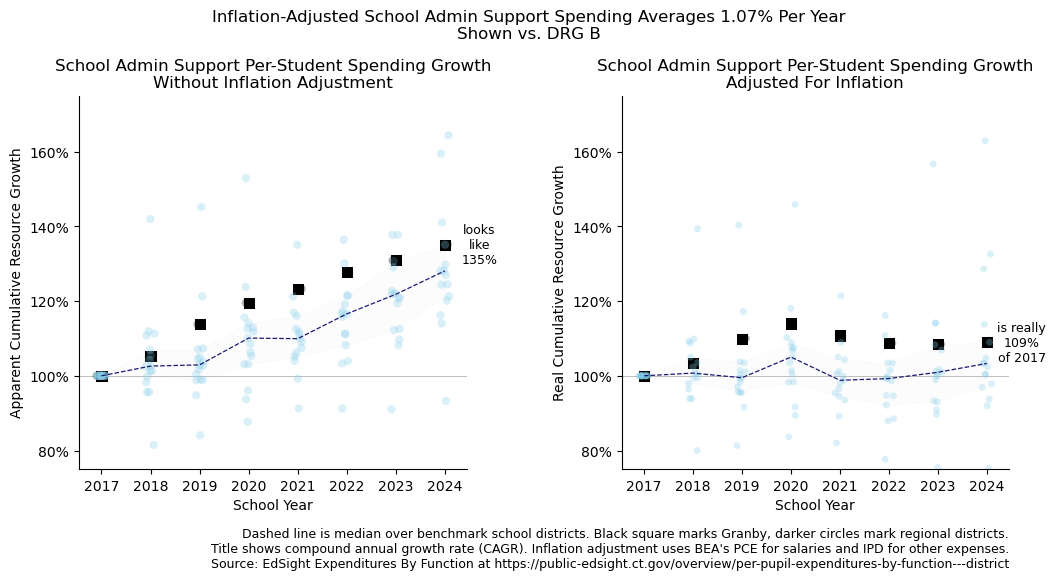

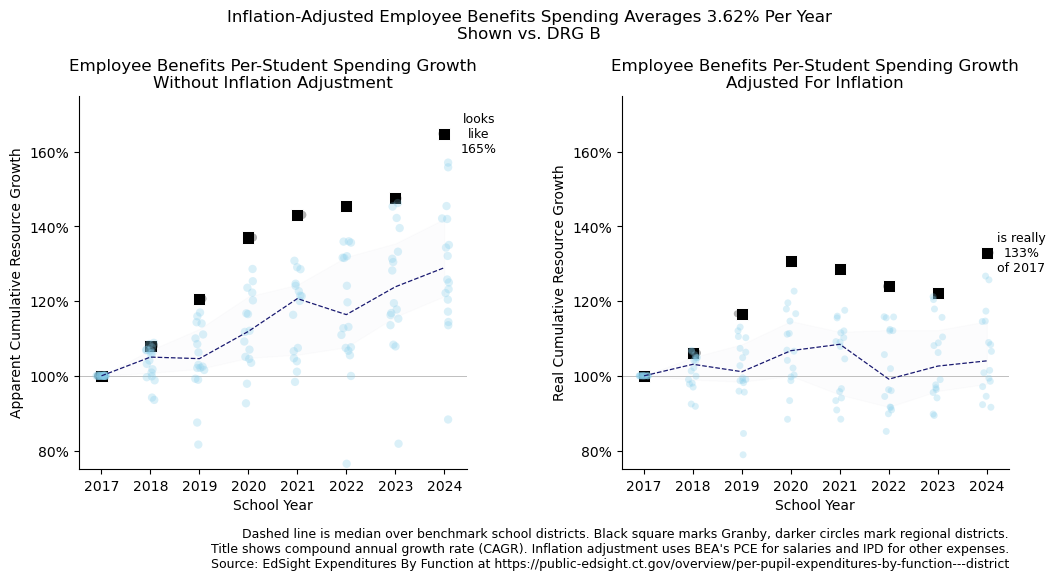

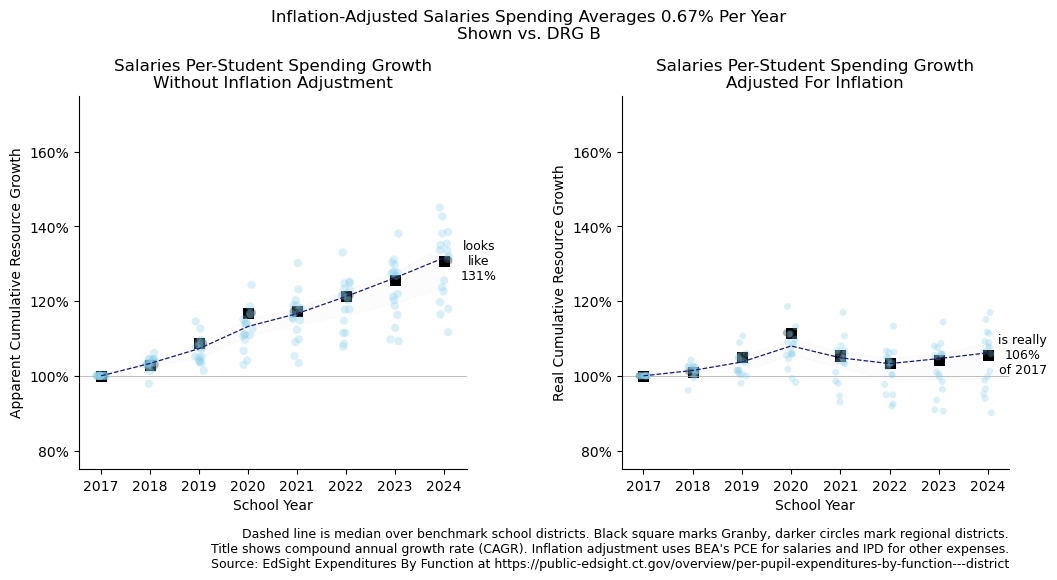

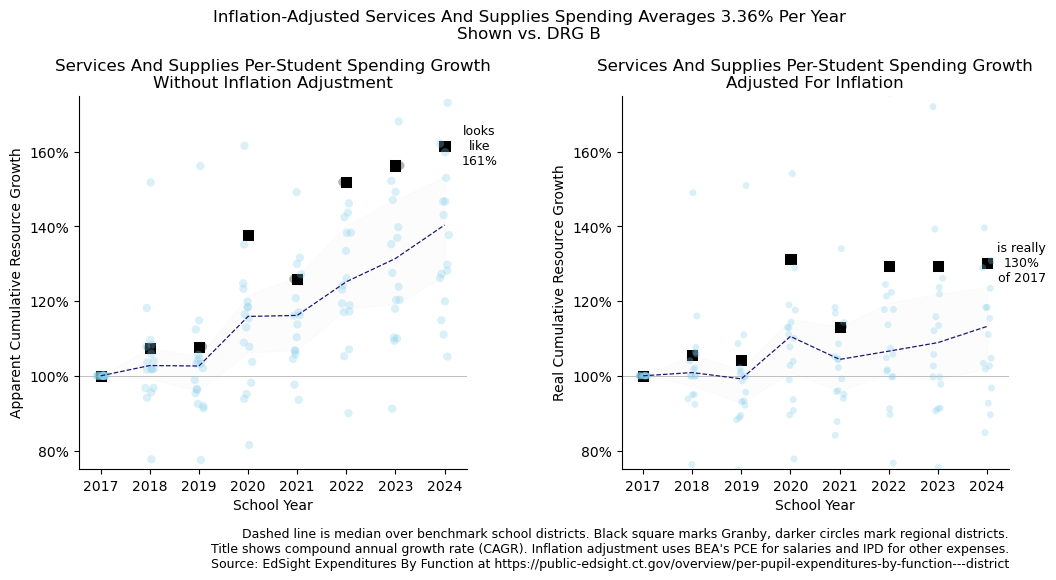

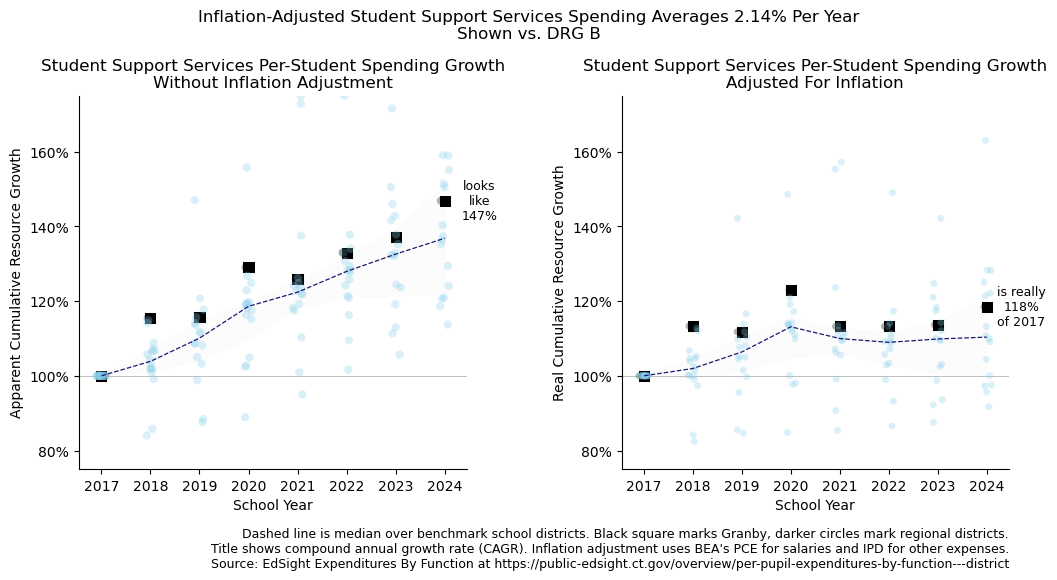

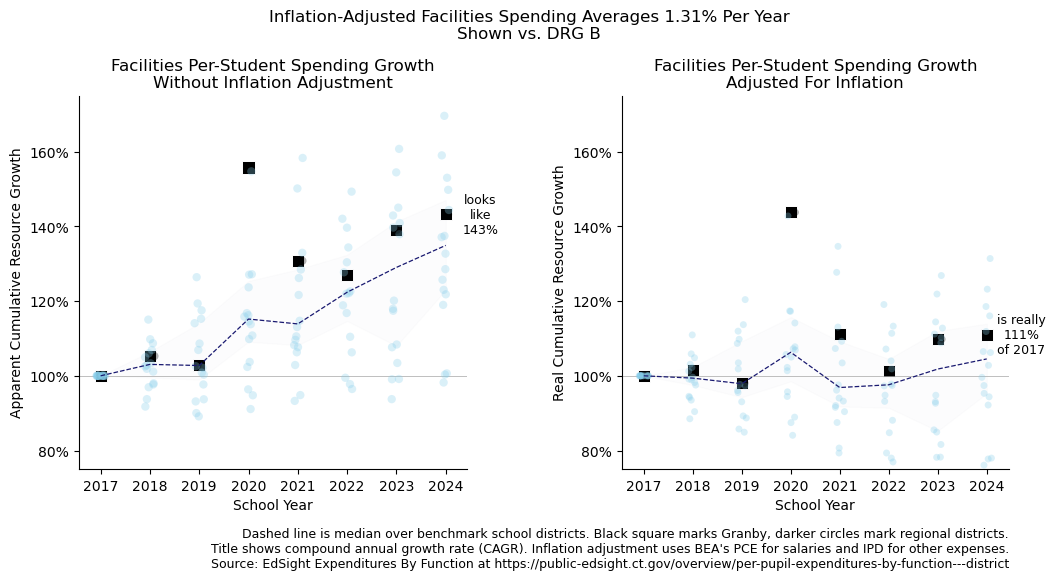

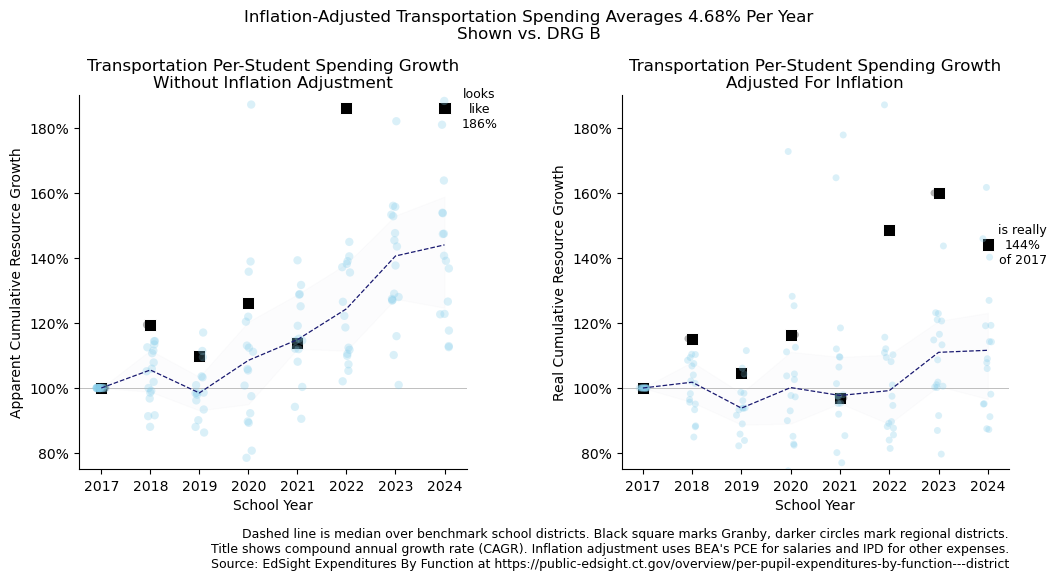

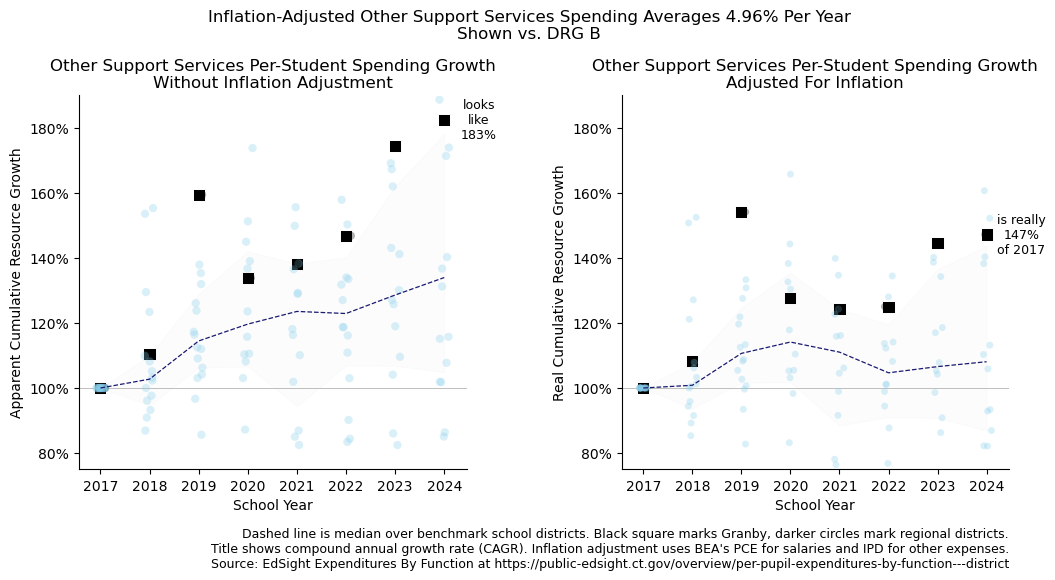

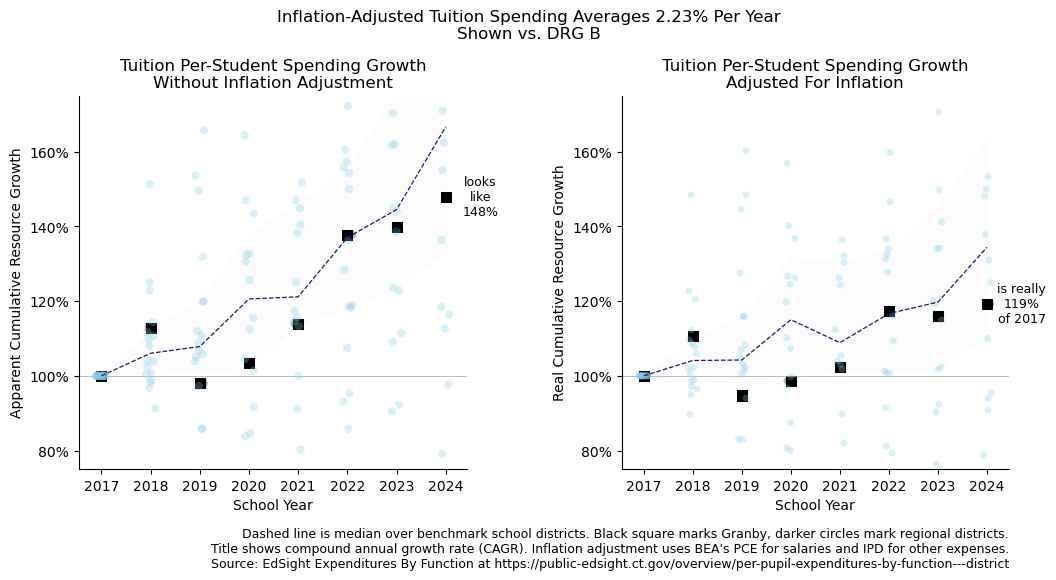

In [26]:
_functionlist = {'Total': 'Total',
                 'Instruction': 'Instruction',
                 'Support services - instruction': 'Instructional Support',
                 'Support services - general administration': 'General Admin Support',
                 'Support services - school based administration': 'School Admin Support',
                 'Employee Benefits': 'Employee Benefits',
                 'Salaries': 'Salaries',
                 'Services And Supplies': 'Services And Supplies',
                 'Support services - students': 'Student Support Services',
                 'Operation and maintenance of plant': 'Facilities',
                 'Student transportation services': 'Transportation',
                 'Central and other support services': 'Other Support Services',
                 'Tuitition': 'Tuition'
                 }

for k, item in _functionlist.items():
    _df = peer_expenditures[(peer_expenditures['Function'] == k)
                                               & (peer_expenditures['School Year'] > '2016')]
    
    with warnings.catch_warnings(action="ignore"):
    
        fig, axs = plt.subplots(1, 2, figsize=(12,5.75), gridspec_kw={'wspace':.4})
    
        # first plot
        g = axs[0]
        g.set_title(f"{item} Per-Student Spending Growth\nWithout Inflation Adjustment")
        g = sns.stripplot(data=_df,
                          x='School Year', y='PPE Growth',  ax=axs[0],
                          palette=peer_cols, legend=None, size=6, alpha=.3,
                          hue = PEERVAR)
        
        sns.scatterplot(x='School Year', y='Granby PPEG', color='black', 
                        size='Granby', sizes=[60, 76], legend=None, ax=g,
                        style='Granby', markers={'Granby': 's', 'Other': 'o'},
                        data=_df)
        
        sns.lineplot(data=_df,
                     x='School Year', y='PPE Growth', estimator='median', color='midnightblue', ax=g,
                     err_kws={'alpha':.01}, lw=.9, ls="--", zorder=5)
    
        g.set_ylabel("Apparent Cumulative Resource Growth")
        _infl = _df[(_df['School Year'] == _df['School Year'].max()) & (_df.Town == 'Granby')]['Granby PPEG'].item()
        
        g.annotate(f"looks\nlike\n{_infl:.0%}", (_df['School Year'].max(), min(1.9, _infl)), 
                 xytext=(25,0), textcoords='offset points', va='center', ha='center', fontsize=9)
    
        # second plot
        h = axs[1]
        h.set_title(f"{item} Per-Student Spending Growth\nAdjusted For Inflation")
        h = sns.stripplot(data=_df,
                          x='School Year', y='Real PPE Growth', alpha=.3,
                          palette=peer_cols, legend=None, ax=axs[1], 
                          hue = PEERVAR)
        
        sns.scatterplot(x='School Year', y='Granby Real PPEG', color='black', 
                        size='Granby', sizes=[60, 76], legend=None, ax=h,
                        style='Granby', markers={'Granby': 's', 'Other': 'o'},
                        data=_df)
        
        sns.lineplot(data=_df,
                     x='School Year', y='Real PPE Growth', estimator='median', color='midnightblue', ax=h,
                     err_kws={'alpha':.01}, lw=.9, ls="--", zorder=5)
    
        h.set_ylabel("Real Cumulative Resource Growth")
        
        _infl = _df[(_df['School Year'] == _df['School Year'].max()) & (_df.Town == 'Granby')]['Granby Real PPEG'].item()
        h.annotate(f"is really\n{_infl:.0%}\nof {_df['School Year'].min()}", (_df['School Year'].max(), _infl), 
                 xytext=(25,0), textcoords='offset points', va='center', ha='center', fontsize=9)
    
        for ax in axs:
            ax.set(ylim=(0.75,1.75))
            ax.axhline(y=1, c='darkgray', ls='-', lw=.7, alpha=.75)
            ax.yaxis.set_major_formatter(perci_formatter)
            
            if ax.get_title().startswith('Transp'):
                ax.set_ylim(top=1.9)
        
            if ax.get_title().startswith('Other'):
                ax.set_ylim(top=1.9)

       
        sns.despine()

        _median = _df[_df['School Year'] == _df['School Year'].max()]['Real PPE Growth'].median()
        _years = _df['School Year'].nunique()
        _cagr = (_infl**(1/_years)) - 1

        _qual = f"Averages {_cagr:.2%} Per Year" 
        
        fig.suptitle(f"Inflation-Adjusted {item} Spending {_qual}\nShown vs. {PEERVAL}")
    
        plt.tight_layout()
        plt.subplots_adjust(top=.83, bottom=0.18)
        line1 = "Dashed line is median over benchmark school districts. Black square marks Granby, darker circles mark regional districts.\n"
        line2 = "Title shows compound annual growth rate (CAGR). Inflation adjustment uses BEA's PCE for salaries and IPD for other expenses.\n"
        line3 = "Source: EdSight Expenditures By Function at https://public-edsight.ct.gov/overview/per-pupil-expenditures-by-function---district"
        fig.text(.9, .01, line1 + line2 + line3, ha='right', fontsize=9)
        
        plt.savefig(f"./charts/peer_districts/{PEERVAR}/apparent_v_real_{item.split()[0].lower()}_growth.png", dpi=200, metadata=png_metadata)
    
    
        plt.show()

### One-Pagers
#### Nominal

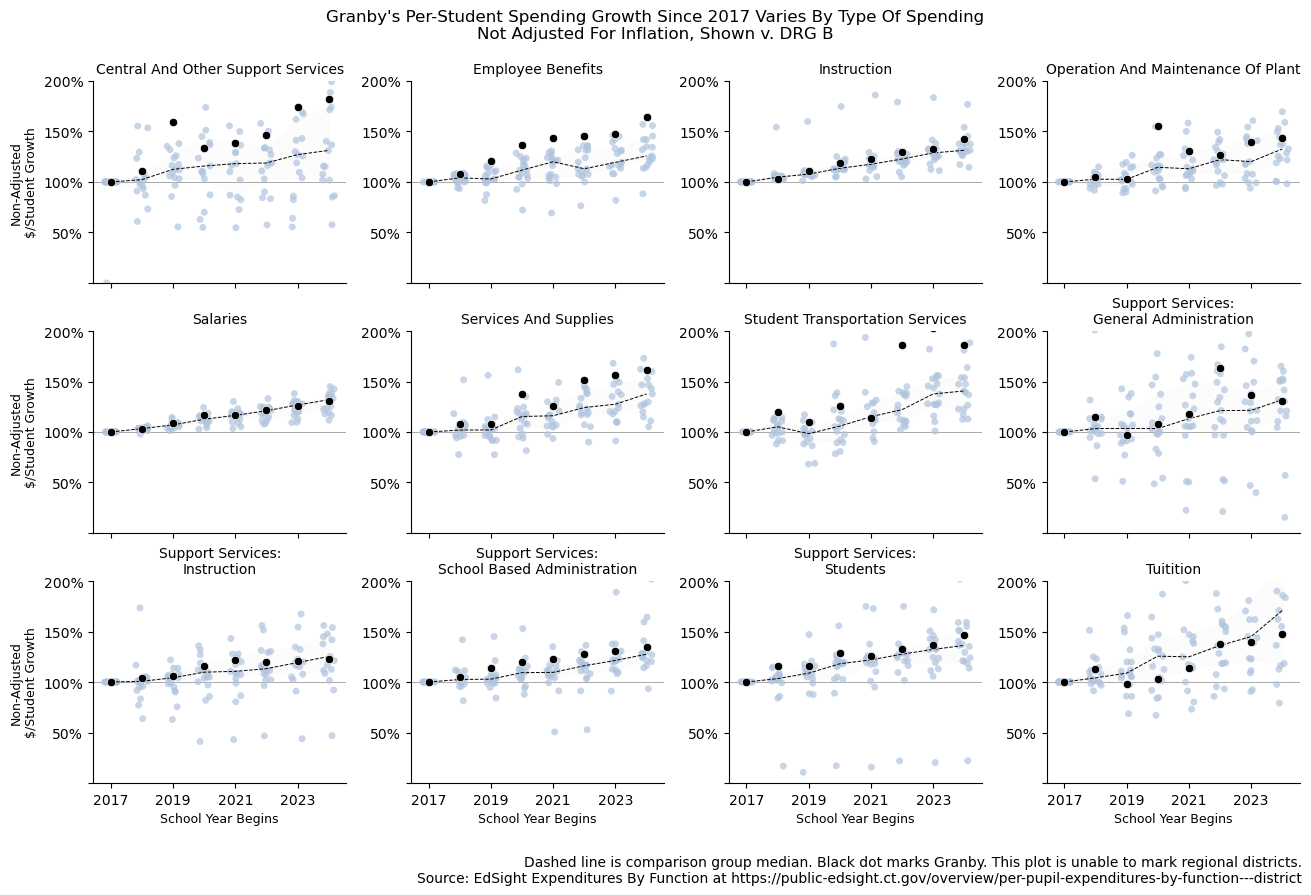

In [27]:
# BECAUSE OVERLAY ONTO CATPLOT X-AXIS NEEDS TO BE STRING
# Need a copy to avoid Granby b/c jitter prevents overlay
_df = data=peer_expenditures[(~peer_expenditures['Function'].str.startswith('Total'))
                  & (peer_expenditures['School Year'] > '2016')]\
            [['School Year', 'District', 'Town', 'Function', 'PPE Growth', 'Granby PPEG']].copy()
_df['PPE Growth'] = _df['PPE Growth'].where(_df['Town'] != 'Granby', np.nan)

g = sns.catplot(_df,
                  x='School Year', y='PPE Growth', hue='District', kind='strip', jitter=.2,
                  col='Function', col_wrap=4, legend=False, sharey=False,
                  alpha=.7, height=3, aspect=1.1, palette=school_cols)

# make sure granby on top
g.map_dataframe(sns.scatterplot, x='School Year', y='Granby PPEG', color='black', zorder=10)
g.map_dataframe(sns.lineplot, x='School Year', y='PPE Growth', estimator='median', markers=False,
                color='black', err_kws={'alpha':.01}, lw=.7, ls="--", zorder=5)

g.set_titles("{col_name}")
g.set_ylabels("Non-Adjusted\n$/Student Growth", fontsize=9)
g.set_xlabels("School Year Begins", fontsize=9)
g.set(ylim=(0,2))
doit=0

for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(perci_formatter)
    ax.axhline(y=1, c='darkgray', ls='-', lw=.7)
    # Get the current title text
    current_title = ax.get_title()
    # Apply the function and set the new title
    ax.set_title(split_function(current_title), fontsize=10, y=1)
    xt = ax.get_xticks()
    if (len(xt) > 1) & (doit==0):
       doit=1
       ax.set_xticks(ticks=xt[::2])
    
    yt = ax.get_yticks()
    doit=0
    if (len(yt) > 1) & (doit==0):
       doit=1
       ax.set_yticks(ticks=yt[::2])

    # no zero
    labels = ax.yaxis.get_ticklabels()
    labels[0].set_visible(False)

plt.tight_layout()

plt.subplots_adjust(top=.9, bottom=0.12)

g.fig.suptitle(f"Granby's Per-Student Spending Growth Since 2017 Varies By Type Of Spending\nNot Adjusted For Inflation, Shown v. {PEERVAL}")

line1 = "Dashed line is comparison group median. Black dot marks Granby. This plot is unable to mark regional districts.\n"
line2 = "Source: EdSight Expenditures By Function at https://public-edsight.ct.gov/overview/per-pupil-expenditures-by-function---district"
g.fig.text(.99, .01, line1 + line2, ha='right', fontsize=10)
    
plt.savefig(f"./charts/peer_districts/{PEERVAR}/spending_growth_facet_nominal.png", dpi=200, metadata=png_metadata)

plt.show()

#### Inflation-Adjusted

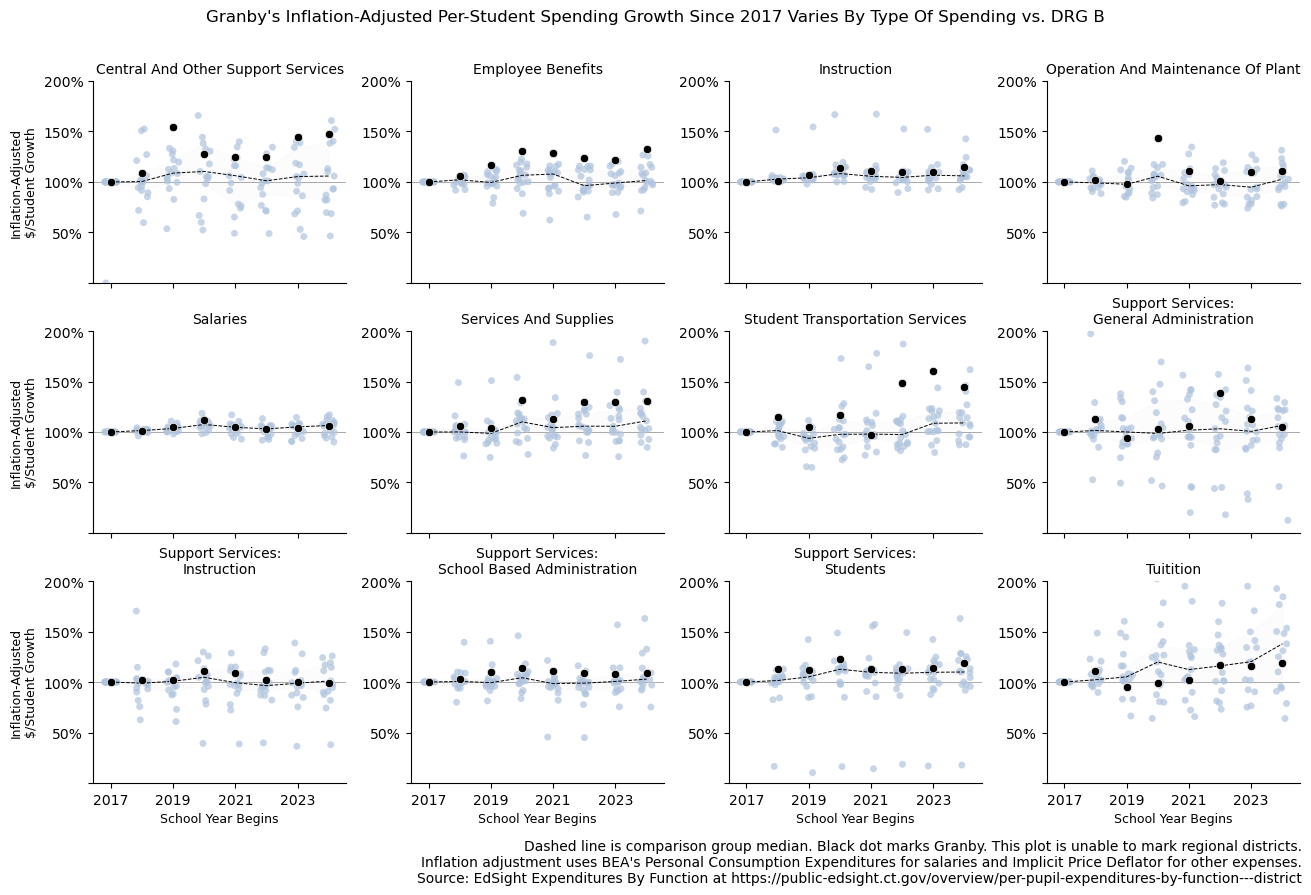

In [28]:
# BECAUSE OVERLAY ONTO CATPLOT X-AXIS NEEDS TO BE STRING
# Need a copy to avoid Granby b/c jitter prevents overlay
_df = data=peer_expenditures[(~peer_expenditures['Function'].str.startswith('Total'))
                  & (peer_expenditures['School Year'] > '2016')]\
            [['School Year', 'District', 'Town', 'Function', 'Real PPE Growth', 'Granby Real PPEG']].copy()
_df['Real PPE Growth'] = _df['Real PPE Growth'].where(_df['Town'] != 'Granby', np.nan)

g = sns.catplot(_df,
                  x='School Year', y='Real PPE Growth', hue='District', kind='strip', jitter=.2,
                  col='Function', col_wrap=4, legend=False, sharey=False,
                  alpha=.7, height=3, aspect=1.1, palette=school_cols)

# make sure granby on top
g.map_dataframe(sns.scatterplot, x='School Year', y='Granby Real PPEG', color='black', zorder=10)
g.map_dataframe(sns.lineplot, x='School Year', y='Real PPE Growth', estimator='median', markers=False,
                color='black', err_kws={'alpha':.01}, lw=.7, ls="--", zorder=5)

g.set_titles("{col_name}")
g.set_ylabels("Inflation-Adjusted\n$/Student Growth", fontsize=9)
g.set_xlabels("School Year Begins", fontsize=9)
g.set(ylim=(0,2))
doit=0

for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(perci_formatter)
    ax.axhline(y=1, c='darkgray', ls='-', lw=.7)
    # Get the current title text
    current_title = ax.get_title()
    # Apply the function and set the new title
    ax.set_title(split_function(current_title), fontsize=10, y=1)
    xt = ax.get_xticks()
    if (len(xt) > 1) & (doit==0):
       doit=1
       ax.set_xticks(ticks=xt[::2])
    
    yt = ax.get_yticks()
    doit=0
    if (len(yt) > 1) & (doit==0):
       doit=1
       ax.set_yticks(ticks=yt[::2])

    # no zero
    labels = ax.yaxis.get_ticklabels()
    labels[0].set_visible(False)
    
plt.tight_layout()

plt.subplots_adjust(top=.9, bottom=0.12)

g.fig.suptitle(f"Granby's Inflation-Adjusted Per-Student Spending Growth Since 2017 Varies By Type Of Spending vs. {PEERVAL}")

line1 = "Dashed line is comparison group median. Black dot marks Granby. This plot is unable to mark regional districts.\n"
line2 = "Inflation adjustment uses BEA's Personal Consumption Expenditures for salaries and Implicit Price Deflator for other expenses.\n"
line3 = "Source: EdSight Expenditures By Function at https://public-edsight.ct.gov/overview/per-pupil-expenditures-by-function---district"
g.fig.text(.99, .01, line1 + line2 + line3, ha='right', fontsize=10)
    
plt.savefig(f"./charts/peer_districts/{PEERVAR}/spending_growth_facet_real.png", dpi=200, metadata=png_metadata)

plt.show()

#### Historical

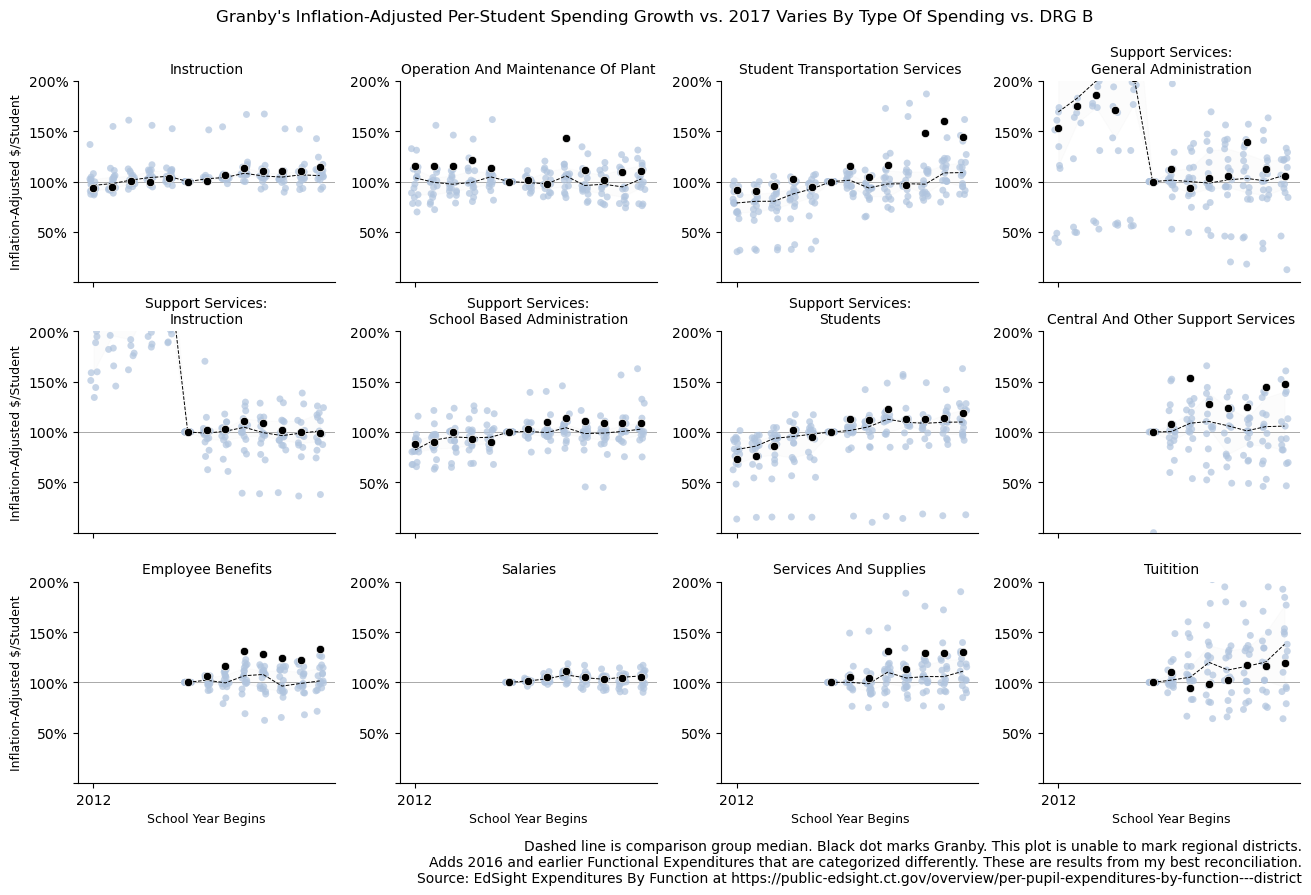

In [29]:
# BECAUSE OVERLAY ONTO CATPLOT X-AXIS NEEDS TO BE STRING
# Need a copy to avoid Granby b/c jitter prevents overlay
_df = data=peer_expenditures[(~peer_expenditures['Function'].str.startswith('Total'))
                & (~peer_expenditures['Function'].str.startswith('Admin'))
                  ]\
            [['School Year', 'District', 'Town', 'Function', 'Real PPE Growth', 'Granby Real PPEG']].copy()
_df['Real PPE Growth'] = _df['Real PPE Growth'].where(_df['Town'] != 'Granby', np.nan)

g = sns.catplot(_df,
                  x='School Year', y='Real PPE Growth', hue='District', kind='strip', jitter=.2,
                  col='Function', col_wrap=4, legend=False, sharey=False,
                  alpha=.7, height=3, aspect=1.1, palette=school_cols)

# make sure granby on top
g.map_dataframe(sns.scatterplot, x='School Year', y='Granby Real PPEG', color='black', zorder=10)
g.map_dataframe(sns.lineplot, x='School Year', y='Real PPE Growth', estimator='median', markers=False,
                color='black', err_kws={'alpha':.01}, lw=.7, ls="--", zorder=5)

g.set_titles("{col_name}")

g.set_ylabels("Inflation-Adjusted $/Student", fontsize=9)
g.set_xlabels("School Year Begins", fontsize=9)

g.set(ylim=(0,2))


for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(perci_formatter)
    ax.axhline(y=1, c='darkgray', ls='-', lw=.7)
    # Get the current title text
    current_title = ax.get_title()
    # Apply the function and set the new title
    ax.set_title(split_function(current_title), fontsize=10, y=1)
    
    xt = ax.get_xticks()
    doit=0
    if (len(xt) > 1) & (doit==0):
       doit=1
       ax.set_xticks(ticks=xt[::2])
    
    yt = ax.get_yticks()
    doit=0
    if (len(yt) > 1) & (doit==0):
       doit=1
       ax.set_yticks(ticks=yt[::2])

    # no zero
    labels = ax.yaxis.get_ticklabels()
    labels[0].set_visible(False)

plt.tight_layout()

plt.subplots_adjust(top=.9, bottom=0.12)

g.fig.suptitle(f"Granby's Inflation-Adjusted Per-Student Spending Growth vs. 2017 Varies By Type Of Spending vs. {PEERVAL}")

line1 = "Dashed line is comparison group median. Black dot marks Granby. This plot is unable to mark regional districts.\n"
line2 = "Adds 2016 and earlier Functional Expenditures that are categorized differently. These are results from my best reconciliation.\n"
line3 = "Source: EdSight Expenditures By Function at https://public-edsight.ct.gov/overview/per-pupil-expenditures-by-function---district"
g.fig.text(.99, .01, line1 + line2 + line3, ha='right', fontsize=10)
    
plt.savefig(f"./charts/peer_districts/{PEERVAR}/spending_growth_facet_historical.png", dpi=200, metadata=png_metadata)

plt.show()

## Per Student Spending
### By Functional Expenditure

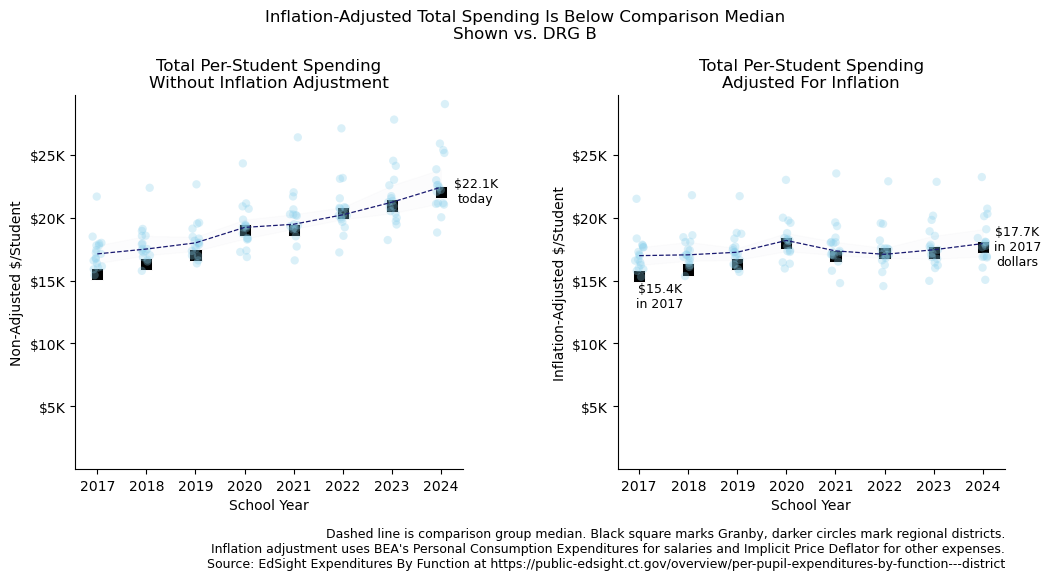

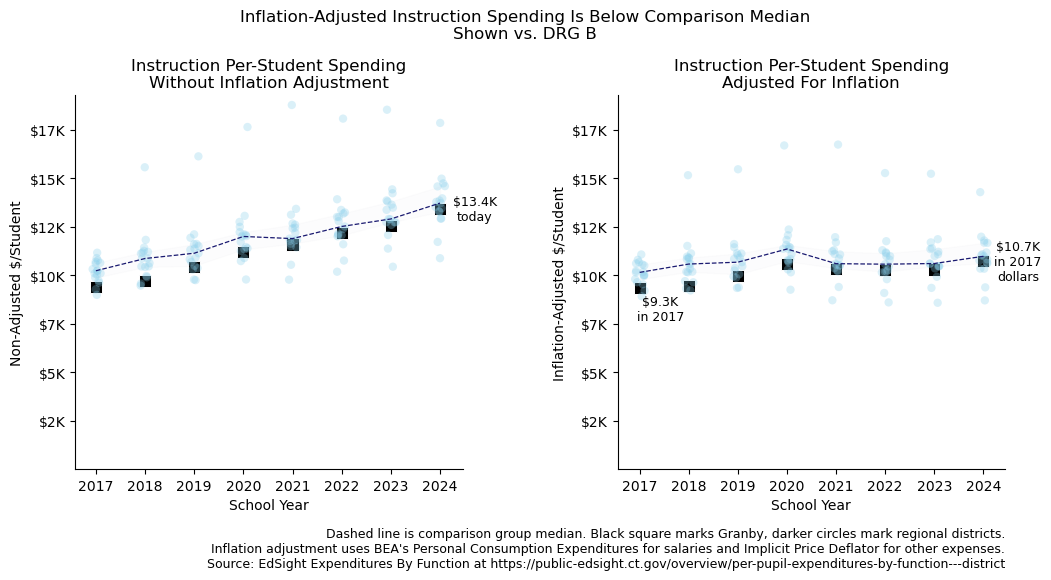

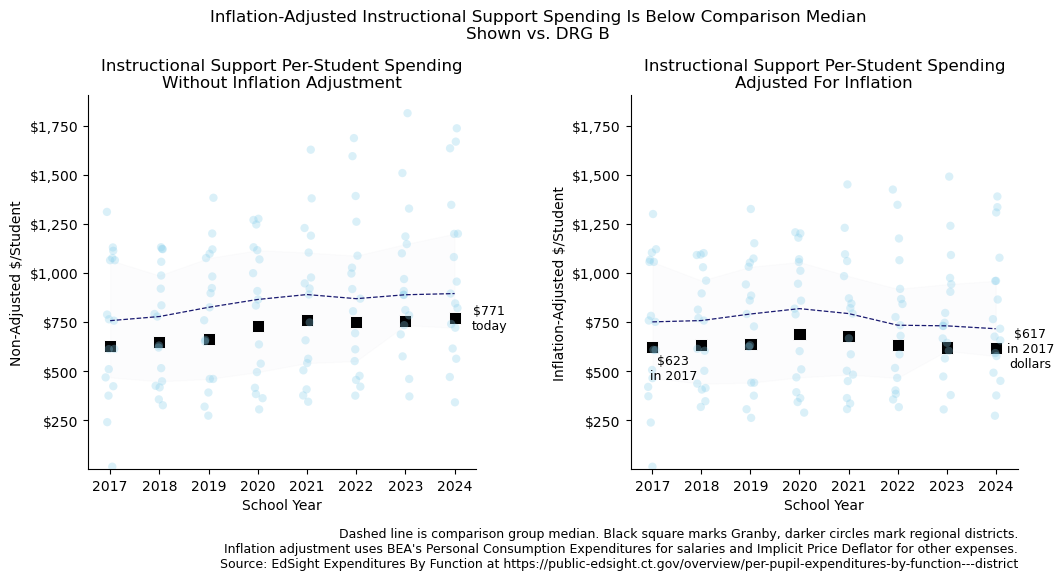

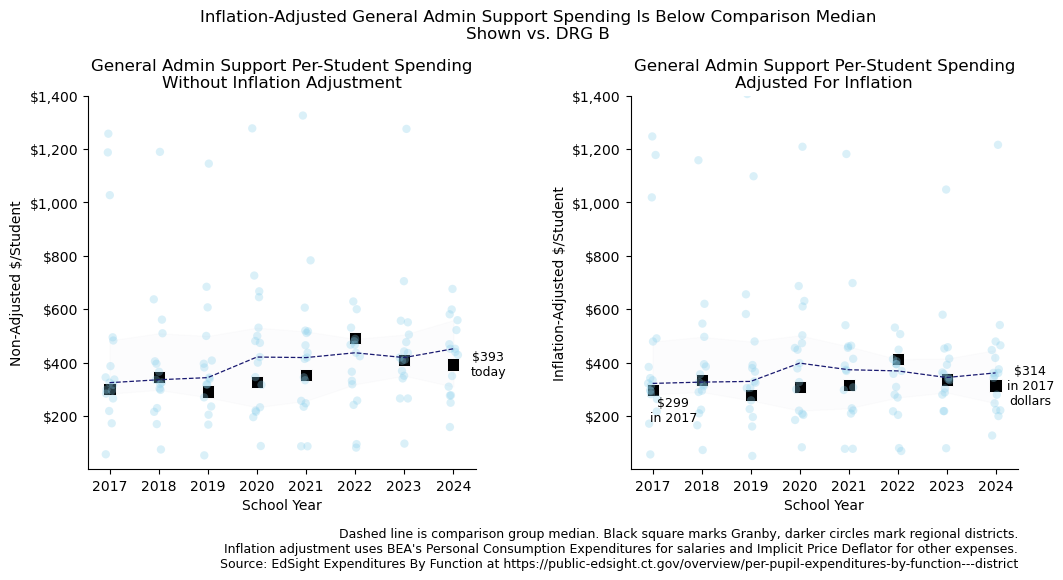

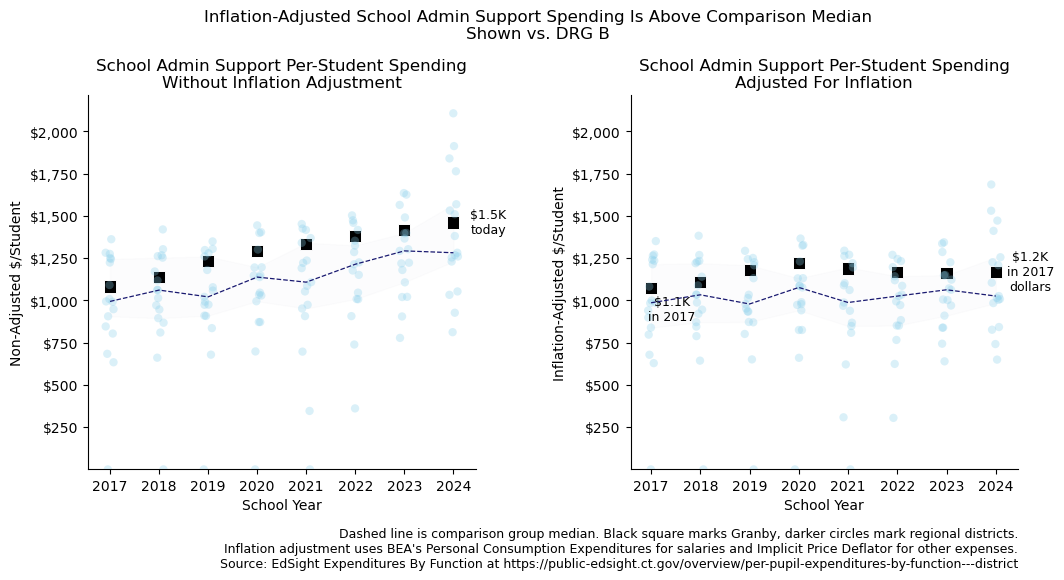

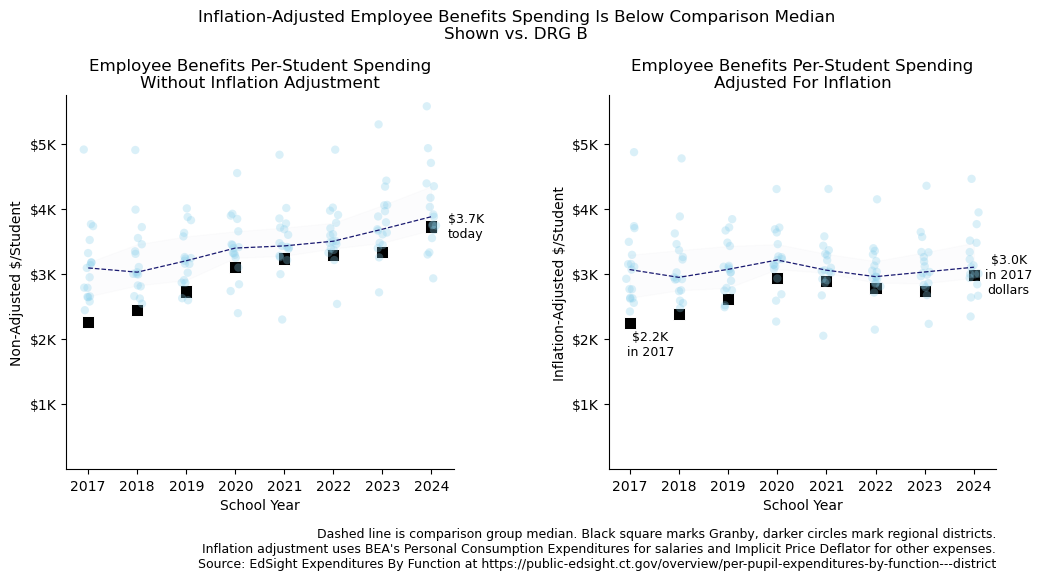

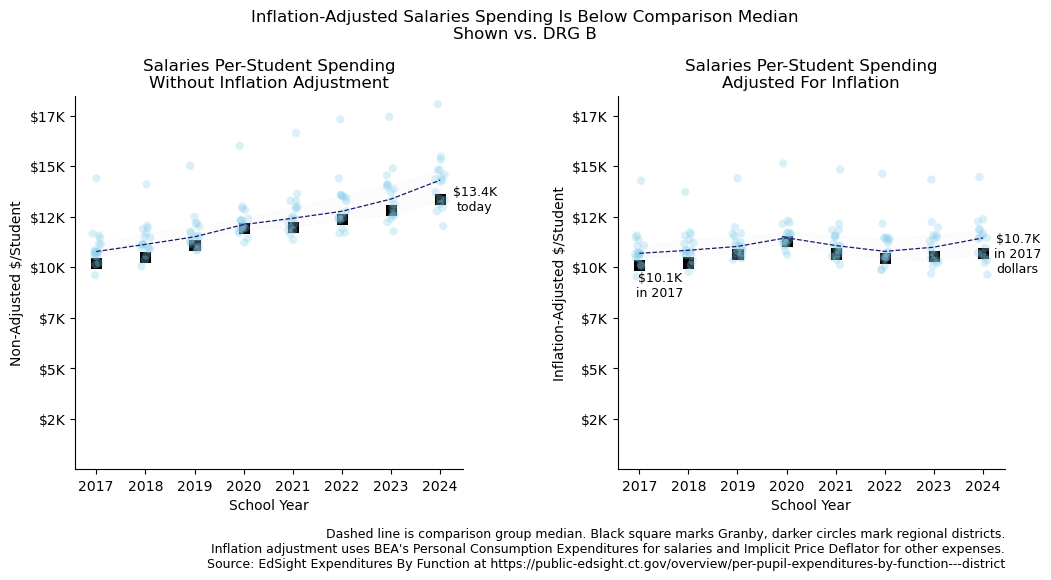

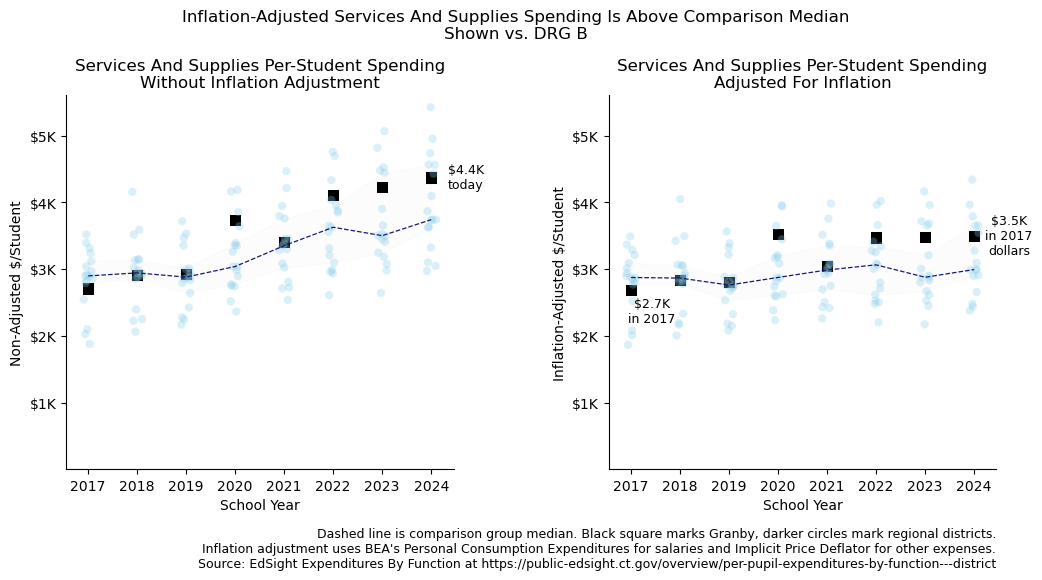

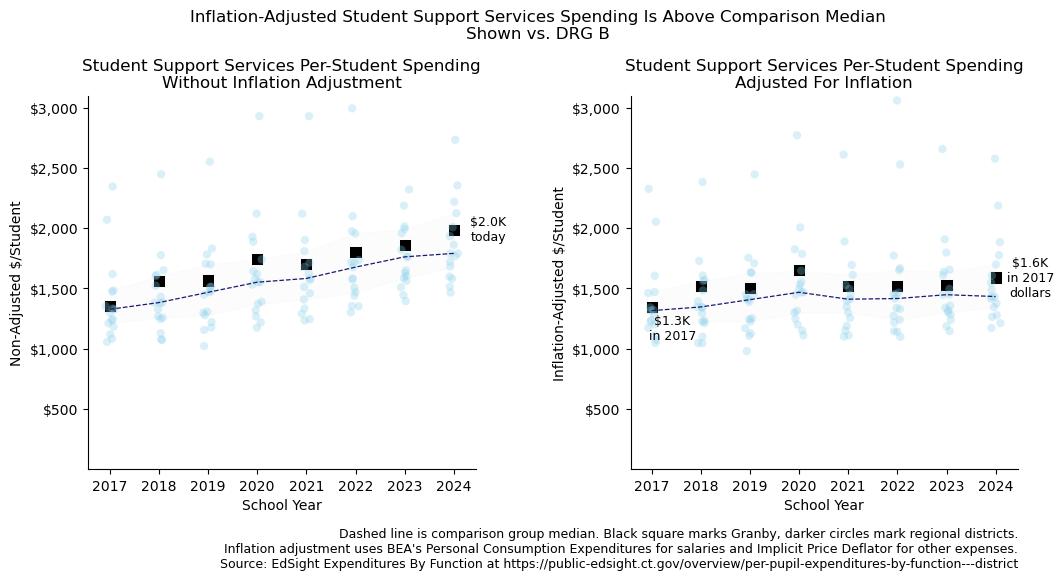

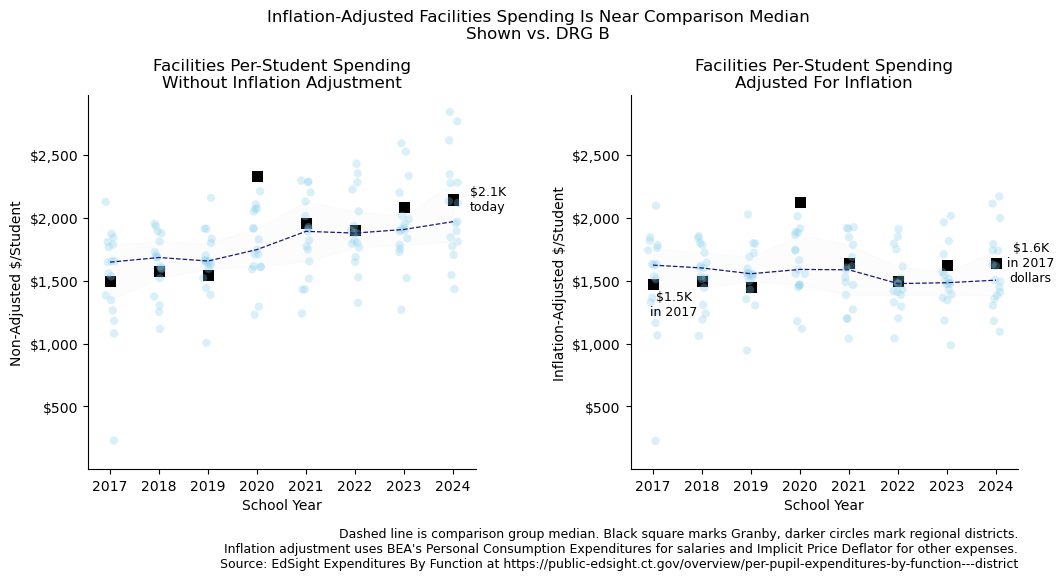

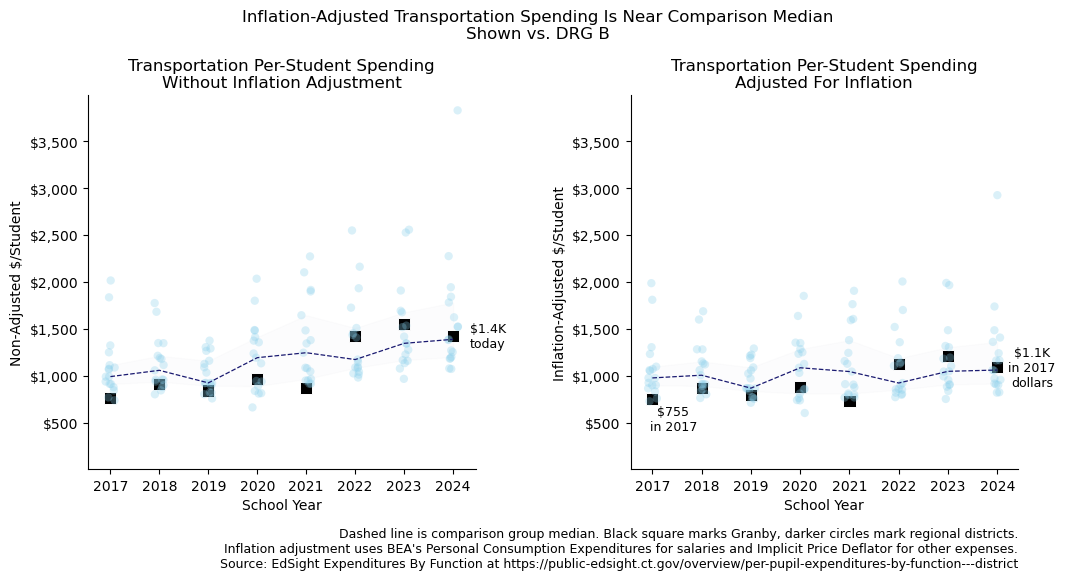

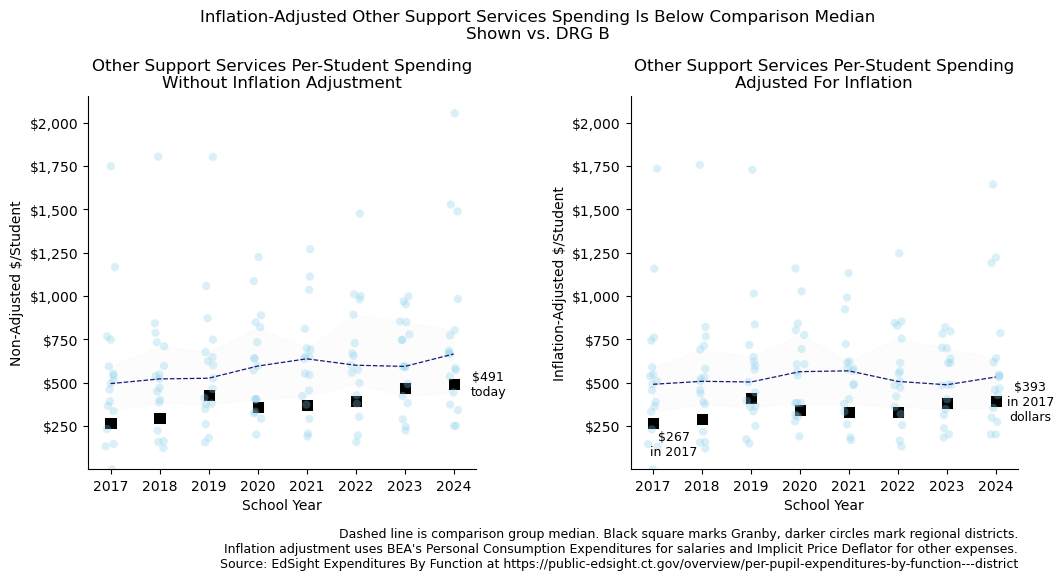

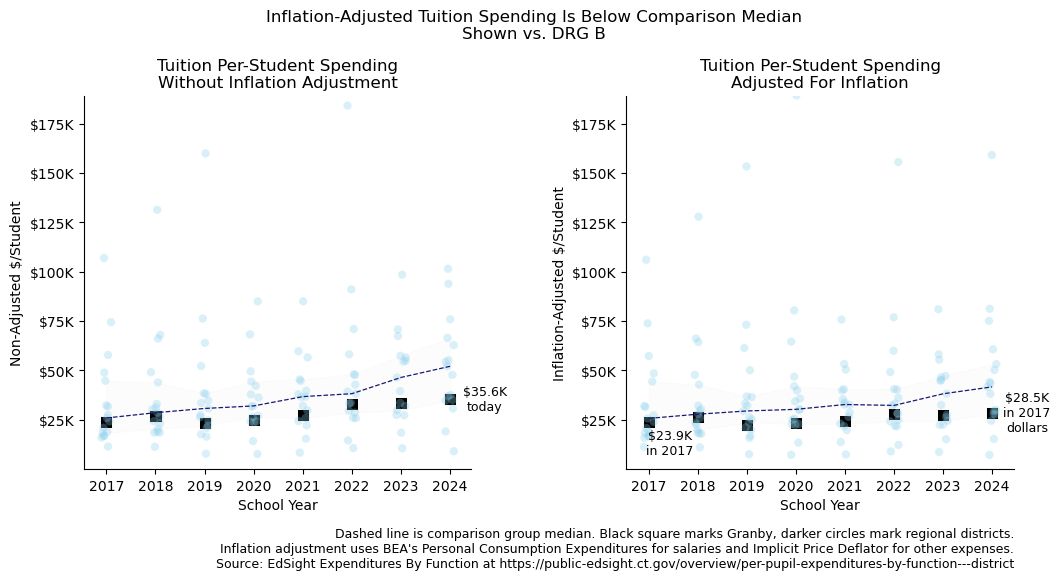

In [33]:

for k, item in _functionlist.items():

    _df = data=peer_expenditures[(peer_expenditures['Function'].str.startswith(k))
                      & (peer_expenditures['School Year'] > '2016')]\
                [['School Year', 'District', 'Town', 'Granby', f"{PEERVAR}", 'Function', 'PPE', 'Real PPE']].copy()

    # need a granby series
    _df['Granby PPE'] = _df['PPE'].where(_df['Town'] == 'Granby', None)
    _df['PPE'] = _df['PPE'].where(_df['Town'] != 'Granby', np.nan)
    _df['Granby Real PPE'] = _df['Real PPE'].where(_df['Town'] == 'Granby', None)
    _df['Real PPE'] = _df['Real PPE'].where(_df['Town'] != 'Granby', np.nan)

    
    with warnings.catch_warnings(action="ignore"):
    
        fig, axs = plt.subplots(1, 2, figsize=(12,5.75), gridspec_kw={'wspace':.4})
    
        # first plot
        g = axs[0]
        g.set_title(f"{item} Per-Student Spending\nWithout Inflation Adjustment")
        g = sns.stripplot(data=_df,
                          x='School Year', y='PPE', alpha=.3,
                          ax=axs[0], size=6,
                          palette=peer_cols, legend=None,
                          hue = PEERVAR)
        
        sns.scatterplot(x='School Year', y='Granby PPE', color='black', 
                        size='Granby', sizes=[60, 76], legend=None, ax=g,
                        style='Granby', markers={'Granby': 's', 'Other': 'o'},
                        data=_df)
        
        sns.lineplot(data=_df,
                     x='School Year', y='PPE', estimator='median', color='midnightblue', ax=g,
                     err_kws={'alpha':.01}, lw=.9, ls="--", zorder=5)
    
        g.set_ylabel("Non-Adjusted $/Student")
        
        _infl = _df[(_df['School Year'] == _df['School Year'].max()) & (_df.Town == 'Granby')]['Granby PPE'].item()
        if _infl > 1000 :
            annt = f"${_infl / 1000:.1f}K\ntoday"
        else:
            annt = f"${_infl:,.0f}\ntoday"
            
        g.annotate(annt, (_df['School Year'].max(), _infl), 
                 xytext=(25,0), textcoords='offset points', ha='center', va='center', fontsize=9)
    
        # second plot
        h = axs[1]
        h.set_title(f"{item} Per-Student Spending\nAdjusted For Inflation")
        h = sns.stripplot(data=_df,
                          x='School Year', y='Real PPE',
                          alpha=.3, size=6,
                          palette=peer_cols, legend=None, ax=axs[1],
                          hue = PEERVAR)
        
        sns.scatterplot(x='School Year', y='Granby Real PPE', color='black', 
                        size='Granby', sizes=[60, 76], legend=None, ax=h,
                        style='Granby', markers={'Granby': 's', 'Other': 'o'},
                        data=_df)
        
        sns.lineplot(data=_df,
                     x='School Year', y='Real PPE', estimator='median', color='midnightblue', ax=h,
                     err_kws={'alpha':.01}, lw=.9, ls="--", zorder=5)
    
        h.set_ylabel("Inflation-Adjusted $/Student")
        
        _infl = _df[(_df['School Year'] == _df['School Year'].max()) & (_df.Town == 'Granby')]['Granby Real PPE'].item()
        
        if _infl > 1000 :
            annt = f"${_infl / 1000:.1f}K\nin 2017\ndollars"
        else:
            annt = f"${_infl:,.0f}\nin 2017\ndollars"
        h.annotate(annt, (_df['School Year'].max(), _infl), 
                 xytext=(25,0), textcoords='offset points', ha='center', va='center', fontsize=9)
        
        _strt = _df[(_df['School Year'] == _df['School Year'].min()) & (_df.Town == 'Granby')]['Granby Real PPE'].item()
        
        if _strt > 1000 :
            annt = f"${_strt / 1000:.1f}K\nin 2017"
        else:
            annt = f"${_strt:,.0f}\nin 2017"
        h.annotate(annt, (_df['School Year'].min(), _strt), 
                 xytext=(15,-5), textcoords='offset points', ha='center', va='top', fontsize=9)        


        for ax in axs:
            ax.yaxis.set_major_formatter(dollar_k_formatter)
            ax.set_ylim(bottom=1)

        # set top limit
        # same y-scale
        b, t = axs[0].get_ylim()

        # clip outlier
        if t > 4.5 * _df['Real PPE'].median():
            t = round(_df['Real PPE'].nlargest(3).iloc[-1].item(), -2)
        
        # reset limits
        axs[0].set_ylim(b,t)
        axs[1].set_ylim(b,t)

        if t <= 5000:
            axs[0].yaxis.set_major_formatter(dollar_k1_formatter)
            axs[1].yaxis.set_major_formatter(dollar_k1_formatter)
        if t <= 4100:
            axs[0].yaxis.set_major_formatter(dollari_formatter)
            axs[1].yaxis.set_major_formatter(dollari_formatter)
        
        sns.despine()
    
        _median = _df[_df['School Year'] == _df['School Year'].max()]['Real PPE'].median()
        _cagr = (_infl**(1/_years)) - 1

        if _infl < _median:
            _qual = 'Below Comparison Median'
        elif (_infl - _median)/_median < .1:
            _qual = 'Near Comparison Median'
        else:
            _qual = 'Above Comparison Median'
        
        fig.suptitle(f"Inflation-Adjusted {item} Spending Is {_qual}\nShown vs. {PEERVAL}")
        
        plt.tight_layout()
        plt.subplots_adjust(top=.83, bottom=0.18)
        line1 = " Dashed line is comparison group median. Black square marks Granby, darker circles mark regional districts.\n"
        line2 = "Inflation adjustment uses BEA's Personal Consumption Expenditures for salaries and Implicit Price Deflator for other expenses.\n"
        line3 = "Source: EdSight Expenditures By Function at https://public-edsight.ct.gov/overview/per-pupil-expenditures-by-function---district"
        fig.text(.9, .01, line1 + line2 + line3, ha='right', fontsize=9)
    
        
        plt.savefig(f"./charts/peer_districts/{PEERVAR}/apparent_v_real_{item.split()[0].lower()}_ppe.png", dpi=200, metadata=png_metadata)
    
    
        plt.show()

### One-Pagers
#### Inflation-Adjusted

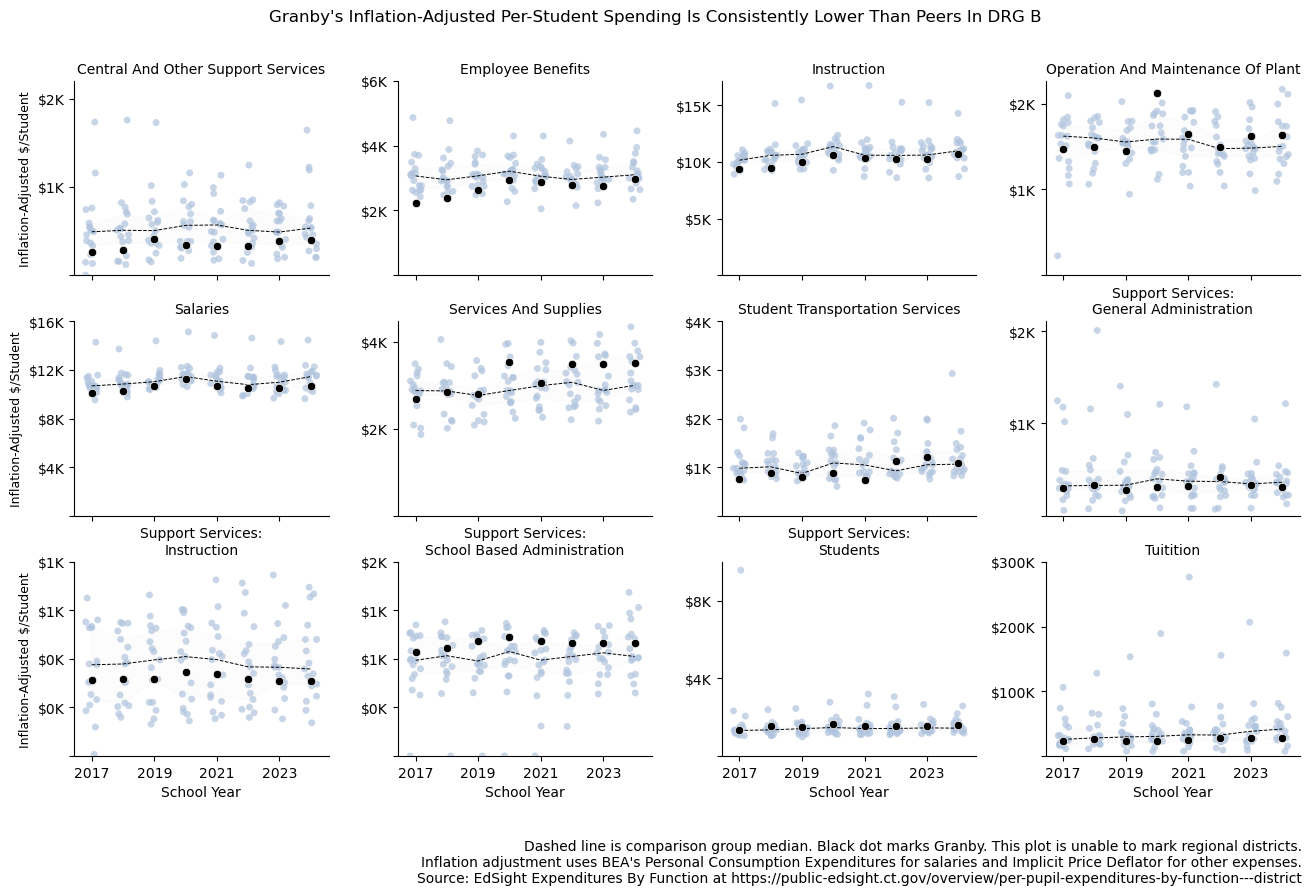

In [31]:
# BECAUSE OVERLAY ONTO CATPLOT X-AXIS NEEDS TO BE STRING
# Need a copy to avoid Granby b/c jitter prevents overlay

_df = data=peer_expenditures[~(peer_expenditures['Function'].str.startswith('Tota'))
                  & (peer_expenditures['School Year'] > '2016')]\
            [['School Year', 'District', 'Town', 'Function', 'Real PPE']].copy()
# need a granby series
_df['Granby Real PPE'] = _df['Real PPE'].where(_df['Town'] == 'Granby', None)
_df['Real PPE'] = _df['Real PPE'].where(_df['Town'] != 'Granby', np.nan)

g = sns.catplot(_df,
                  x='School Year', y='Real PPE', hue='District', kind='strip', jitter=.2,
                  col='Function', col_wrap=4, legend=False, sharey=False,
                  alpha=.7, height=3, aspect=1.1, palette=school_cols)

# make sure granby on top
g.map_dataframe(sns.scatterplot, x='School Year', y='Granby Real PPE', color='black', zorder=10)
g.map_dataframe(sns.lineplot, x='School Year', y='Real PPE', estimator='median', markers=False,
                color='black', err_kws={'alpha':.01}, lw=.7, ls="--", zorder=5)

g.set_titles("{col_name}")
g.set_ylabels("Inflation-Adjusted $/Student", fontsize=9)
doit=0

for ax in g.axes.flat:
    
    # Get the current title text
    # Apply the function and set the new title
    current_title = ax.get_title()
    ax.set_title(split_function(current_title), fontsize=10, y=1)

    ax.yaxis.set_major_formatter(dollar_k_formatter)
    ax.set_ylim(bottom=1)
    
    if ax.get_title().startswith('Student Transp'):
        ax.set_ylim(top=4000)

    if ax.get_title().startswith('Central And O'):
        ax.set_ylim(top=2200)
        
    # thin ticks
    xt = ax.get_xticks()
    if (len(xt) > 1) & (doit==0):
       doit=1
       ax.set_xticks(ticks=xt[::2])
    
    yt = ax.get_yticks()
    doit=0
    if (len(yt) > 5) & (doit==0):
       doit=1
       ax.set_yticks(ticks=yt[::2])

    # no zero
    labels = ax.yaxis.get_ticklabels()
    labels[0].set_visible(False)


plt.tight_layout()

plt.subplots_adjust(top=.9, bottom=0.15)

g.fig.suptitle(f"Granby's Inflation-Adjusted Per-Student Spending Is Consistently Lower Than Peers In {PEERVAL}")

line1 = "Dashed line is comparison group median. Black dot marks Granby. This plot is unable to mark regional districts.\n"
line2 = "Inflation adjustment uses BEA's Personal Consumption Expenditures for salaries and Implicit Price Deflator for other expenses.\n"
line3 = "Source: EdSight Expenditures By Function at https://public-edsight.ct.gov/overview/per-pupil-expenditures-by-function---district"
g.fig.text(.99, .01, line1 + line2 + line3, ha='right', fontsize=10)
    
plt.savefig(f"./charts/peer_districts/{PEERVAR}/ppe_spending_facet_real.png", dpi=200, metadata=png_metadata)

plt.show()